In [1]:
import torch

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA is available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version PyTorch was built with: {torch.version.cuda}")
    print(f"Current CUDA device name: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.6.0+cu124
CUDA is available: True
CUDA version PyTorch was built with: 12.4
Current CUDA device name: NVIDIA A100-SXM4-40GB


In [2]:
!pip install sdv tensorflow -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.0/183.0 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.9/139.9 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.9/13.9 MB 128.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.5/193.5 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 72.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.3/85.3 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 119.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 98.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 54.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66

In [3]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 23.8 MB/s eta 0:00:00


In [4]:
!pip install koreanize_matplotlib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 10.6 MB/s eta 0:00:00


In [5]:
from google.colab import drive
drive.mount('/content/drive/')
path = '/content/drive/MyDrive/거래_이상탐지_프로젝트/data'

Mounted at /content/drive/


In [6]:
import pandas as pd
import numpy as np
from bisect import bisect_left
from dateutil.relativedelta import relativedelta

# 시각화 라이브러리
import matplotlib.pyplot as plt
import seaborn as sns

# SDV (데이터 증강) 라이브러리
from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata

# 전처리 및 모델링 라이브러리
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, RandomizedSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
import lightgbm as lgb
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# 평가 라이브러리
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

# Pipeline 관련
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

import warnings
try:
    import koreanize_matplotlib
except ImportError:
    pass
warnings.filterwarnings('ignore')

In [7]:
train_df = pd.read_csv(path+"/fraudTrain.csv")
test_df = pd.read_csv(path+"/fraudTest.csv")

In [8]:
def calculate_age(born, trans_date):
    """생년월일과 거래 날짜를 이용하여 나이를 계산합니다."""
    return relativedelta(trans_date, born).years

def count_past_days_fast(df, days):
    """
    각 거래 시점을 기준으로 과거 'days' 기간 동안의 거래 횟수를 빠르게 계산합니다.
    df는 'cc_num'과 'trans_date_trans_time'으로 정렬되어 있어야 합니다.
    """
    results = []
    grouped = df.groupby('cc_num')

    for _, group in grouped:
        times = group['trans_date_trans_time'].tolist()
        counts = []
        for i, t in enumerate(times):
            start_time = t - pd.Timedelta(days=days)
            left_idx = bisect_left(times, start_time)
            right_idx = i
            counts.append(right_idx - left_idx)
        results.extend(counts)
    return results

In [9]:
def base_df(df: pd.DataFrame) -> pd.DataFrame:
    """
    원본 데이터프레임에 기본적인 특징 엔지니어링을 적용합니다.
    로그 변환, 표준화, 시간 특징, 거래 빈도, 시간 간격, 나이 등을 포함합니다.
    그래프 구축에 필요한 ID 컬럼들은 유지합니다.
    """
    df_p = df.copy()

    # 불필요한 컬럼 제거 (그래프 구축에 사용되지 않는 원본 컬럼들)
    drop_cols_initial = ['Unnamed: 0', 'unix_time', 'trans_num', 'first', 'last', 'merchant',
                         'street', 'merch_lat', 'merch_long', 'city_pop', 'lat', 'long', 'zip']
    df_p = df_p.drop(columns=drop_cols_initial, errors='ignore')

    # 로그 변환 (amt)
    df_p['amt_log'] = np.log1p(df_p['amt'])

    # 표준화 (amt_log)
    scaler = StandardScaler()
    df_p['amt_log_std'] = scaler.fit_transform(df_p[['amt_log']])

    # datetime 변환 및 시간 관련 특징 추출
    df_p['datetime'] = pd.to_datetime(df_p['trans_date_trans_time'])
    df_p['hour'] = df_p['datetime'].dt.hour
    df_p['day_of_week'] = df_p['datetime'].dt.dayofweek # Monday=0, Sunday=6
    df_p['month'] = df_p['datetime'].dt.month # 1월=1, 12월=12

    # 시간 특징 (Sin/Cos 변환)
    df_p['trans_hour_sin'] = np.sin(2 * np.pi * df_p['hour'] / 24)
    df_p['trans_hour_cos'] = np.cos(2 * np.pi * df_p['hour'] / 24)
    df_p['is_night'] = df_p['hour'].isin([22, 23, 0, 1, 2, 3]).astype(int)

    # 고위험 시간대 특징
    high_risk_days = [2, 3, 4]  # 수, 목, 금
    high_risk_hours = list(range(0, 5)) + [21, 22, 23] # 0~4시, 21~23시
    df_p['is_high_risk_period'] = (
        df_p['day_of_week'].isin(high_risk_days) & df_p['hour'].isin(high_risk_hours)
    ).astype(int)

    # 거래 정렬 (cc_num별로 시간 순서)
    df_p['trans_date_trans_time'] = pd.to_datetime(df_p['trans_date_trans_time'])
    df_p = df_p.sort_values(['cc_num', 'trans_date_trans_time']).reset_index(drop=True)

    # 과거 N일간 거래 횟수
    df_p['cnt_1d'] = count_past_days_fast(df_p, 1)
    df_p['cnt_7d'] = count_past_days_fast(df_p, 7)
    df_p['cnt_30d'] = count_past_days_fast(df_p, 30)

    # 거래 시간 간격 특징
    df_p['next_trans_time'] = df_p.groupby('cc_num')['trans_date_trans_time'].shift(-1)
    df_p['time_since_last_trans'] = (df_p['trans_date_trans_time'] - df_p.groupby('cc_num')['trans_date_trans_time'].shift(1)).dt.total_seconds()
    df_p['time_until_next_trans'] = (df_p['next_trans_time'] - df_p['trans_date_trans_time']).dt.total_seconds()
    df_p[['time_since_last_trans', 'time_until_next_trans']] = df_p[['time_since_last_trans', 'time_until_next_trans']].fillna(0)

    # 나이 관련 특징
    df_p['dob'] = pd.to_datetime(df_p['dob'])
    df_p['age'] = df_p.apply(lambda x: calculate_age(x['dob'], x['trans_date_trans_time']), axis=1)
    df_p['age_group'] = (df_p['age'] // 10) * 10

    # 도시-주 결합 특징
    df_p['city_state'] = df_p['city'] + ', ' + df_p['state']

    # 범주형 변수 원-핫 인코딩
    # df_p = pd.get_dummies(df_p, columns=['category'], prefix='category', drop_first=True)
    # df_p = pd.get_dummies(df_p, columns=['gender'], prefix='gender', drop_first=True)

    final_features_drop_cols = ['cc_num', 'trans_date_trans_time', 'city', 'state', 'dob', 'next_trans_time', 'datetime', 'time_until_next_trans', 'amt_log', 'hour', 'amt']
    df_p = df_p.drop(columns=final_features_drop_cols, errors='ignore')

    return df_p

def preprocess_data(df: pd.DataFrame,
                    hour: str = 'sincos',
                    high_risk_period: bool = False,
                    age_group: bool = False
                    ) -> pd.DataFrame:
    """
    특정 전처리 옵션에 따라 컬럼을 선택하거나 제거합니다.
    Args:
        df: 입력 DataFrame.
        hour: 시간 전처리 방법 ('sincos' 또는 'is_night').
        high_risk_period: 고위험 시간대 컬럼 사용 여부.
        age_group: 연령대 그룹 컬럼 사용 여부.
    """
    df_p = df.copy()

    if hour == 'sincos':
        df_p = df_p.drop(columns=['is_night'], errors='ignore')
    elif hour == 'is_night':
        df_p = df_p.drop(columns=['trans_hour_sin','trans_hour_cos'], errors='ignore')

    if not high_risk_period:
        df_p = df_p.drop(columns=['is_high_risk_period'], errors='ignore')

    if age_group:
        df_p = df_p.drop(columns=['age'], errors='ignore')
    else:
        df_p = df_p.drop(columns=['age_group'], errors='ignore')

    return df_p


In [10]:
# K-Fold, 타겟 인코딩 스무딩 함수
def m_estimate_smoothing(mean, global_mean, count, m):
    """M-estimate 스무딩을 적용하여 평균을 계산합니다."""
    return (mean * count + global_mean * m) / (count + m)

def kfold_target_encoding(df, target_col, cat_cols, n_splits=5, m_param=10):
    """
    K-Fold 교차 검증 방식의 타겟 인코딩을 M-estimate 스무딩과 함께 적용합니다.
    주어진 cat_cols 리스트에 있는 모든 컬럼에 대해 OOF 인코딩을 적용하고,
    각 컬럼에 대한 Full 인코딩 맵과 전역 평균을 반환합니다.

    Args:
        df: 입력 데이터프레임 (훈련 데이터).
        target_col: 타겟 컬럼 이름 (예: 'is_fraud').
        cat_cols: 인코딩하고 값을 덮어쓸 범주형 컬럼 이름의 리스트.
        n_splits: K-Fold 분할 개수.
        m_param: M-estimate 스무딩 파라미터.
    Returns:
        tuple: (OOF 인코딩된 DataFrame, 각 컬럼별 Full 인코딩 맵과 전역 평균을 담은 딕셔너리)
    """
    df_processed = df.copy() # 원본 DataFrame을 직접 수정하지 않기 위해 복사본 사용
    global_mean = df_processed[target_col].mean() # 전체 타겟 변수의 평균 (모든 인코딩에 공통 사용)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    # 각 범주형 컬럼별로 학습된 Full 인코딩 맵과 전역 평균을 저장할 딕셔너리
    all_learned_encoding_info = {}

    # cat_cols가 단일 문자열로 들어올 경우를 대비해 리스트로 변환 (안정성 강화)
    if not isinstance(cat_cols, list):
        cat_cols = [cat_cols]

    for cat_col in cat_cols: # 각 범주형 컬럼에 대해 반복 처리
        print(f"--- '{cat_col}' 컬럼 OOF 인코딩 진행 중 ---")
        temp_oof_encoded_values = np.empty(len(df_processed))
        temp_oof_encoded_values[:] = np.nan # 초기화

        for train_idx, valid_idx in kf.split(df_processed):
            train_fold = df_processed.iloc[train_idx]

            # 훈련 폴드에서 해당 cat_col의 평균 및 개수 집계
            agg = train_fold.groupby(cat_col)[target_col].agg(['mean', 'count']).reset_index()

            # M-estimate 스무딩 적용
            agg['smoothed'] = m_estimate_smoothing(agg['mean'], global_mean, agg['count'], m_param)
            mapping = dict(zip(agg[cat_col], agg['smoothed']))

            # 유효성 검사 폴드의 해당 cat_col 위치에 스무딩된 값을 매핑
            temp_oof_encoded_values[valid_idx] = df_processed.loc[valid_idx, cat_col].map(mapping).fillna(global_mean)

        # 모든 폴드에 대한 처리가 끝난 후, df_processed에 OOF 인코딩된 값을 덮어씁니다.
        df_processed[cat_col] = temp_oof_encoded_values

        # 현재 컬럼에 대한 Full 인코딩 맵 생성 (테스트 데이터 인코딩에 사용될 예정)
        full_agg = df.groupby(cat_col)[target_col].agg(['mean', 'count']).reset_index()
        full_agg['smoothed'] = m_estimate_smoothing(full_agg['mean'], global_mean, full_agg['count'], m_param)
        full_encoding_map = dict(zip(full_agg[cat_col], full_agg['smoothed']))

        # 각 컬럼의 맵과 전역 평균을 딕셔너리에 저장
        all_learned_encoding_info[cat_col] = {
            'map': full_encoding_map,
            'global_mean': global_mean # 각 컬럼별 전역 평균은 동일
        }

    return df_processed, all_learned_encoding_info # OOF 인코딩된 DF와 모든 Full 맵/전역 평균 정보 반환


def test_data_target_encoding(df, cat_cols, learned_encoding_info):
    """
    제공된 인코딩 맵과 전역 평균을 사용하여 테스트 데이터프레임의 여러 컬럼을 인코딩합니다.

    Args:
        df: 입력 데이터프레임 (테스트 데이터).
        cat_cols: 인코딩할 범주형 컬럼 이름의 리스트.
        learned_encoding_info: kfold_target_encoding에서 반환된 학습된 인코딩 정보를 담은 딕셔너리.
                               예: {'col1': {'map': map1, 'global_mean': gm1}, 'col2': {'map': map2, 'global_mean': gm2}}
    Returns:
        인코딩된 컬럼이 덮어씌워진 DataFrame.
    """
    df_processed = df.copy()

    # cat_cols가 단일 문자열로 들어올 경우를 대비해 리스트로 변환 (안정성 강화)
    if not isinstance(cat_cols, list):
        cat_cols = [cat_cols]

    for cat_col in cat_cols:
        if cat_col not in learned_encoding_info:
            print(f"경고: '{cat_col}' 컬럼에 대한 학습된 인코딩 정보가 없습니다. 해당 컬럼은 인코딩되지 않습니다.")
            continue

        encoding_map = learned_encoding_info[cat_col]['map']
        global_mean = learned_encoding_info[cat_col]['global_mean']

        # 인코딩 값 덮어쓰기: 맵에 없는 값은 해당 컬럼의 전역 평균으로 대체
        df_processed[cat_col] = df_processed[cat_col].map(encoding_map).fillna(global_mean)
        print(f"--- '{cat_col}' 컬럼 테스트 데이터 인코딩 완료 ---")

    return df_processed

In [11]:
# 모델 평가 및 시각화 함수
def evaluate_and_visualize(model, X_data, y_data, set_name):
    """모델 평가 및 결과/혼동 행렬 시각화 함수"""
    y_pred = model.predict(X_data)
    y_pred_proba = model.predict_proba(X_data)[:, 1]

    results = {
        'Precision': precision_score(y_data, y_pred),
        'Recall': recall_score(y_data, y_pred),
        'F1-Score': f1_score(y_data, y_pred),
        'ROC_AUC': roc_auc_score(y_data, y_pred_proba)
    }

    print(f"\n--- {set_name} 평가 결과 ---")
    print(pd.DataFrame([results]).to_string())
    print("\nClassification Report:")
    print(classification_report(y_data, y_pred, digits=4))

    # 혼동 행렬 시각화
    cm = confusion_matrix(y_data, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                  xticklabels=['정상(0)', '사기(1)'], yticklabels=['정상(0)', '사기(1)'])
    plt.title(f'Confusion Matrix ({set_name})')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    return results

In [12]:
# --- 데이터 분할 및 1차 전처리 (파이프라인 외부에서 미리 수행할 부분) ---
# 원본 노트북의 데이터 분할 방식 (train_df를 train/val로 나누고 test_df는 별도)
X = train_df.drop('is_fraud', axis=1)
y = train_df['is_fraud']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

df_train = pd.concat([X_train, y_train], axis=1)
df_val = pd.concat([X_val, y_val], axis=1)
df_test = test_df.copy()

# base_df 및 preprocess_data 적용 (이 단계는 파이프라인 외부에 남습니다)
print("[공통 작업] base_df 및 preprocess_data 적용 시작...")
train_temp = preprocess_data(base_df(df_train), high_risk_period=True, age_group=False)
val_temp = preprocess_data(base_df(df_val), high_risk_period=True, age_group=False)
test_temp = preprocess_data(base_df(df_test), high_risk_period=True, age_group=False)
print("기본 전처리 완료.")

# --- GPU 사용 가능 여부 확인 및 설정 ---
use_gpu = torch.cuda.is_available()

m_param_values = [1, 5, 10, 50, 100, 500] # 튜닝할 m_param 값들

# 최적 M-param 조합과 최고 점수 저장 변수
best_m_param_combination = {'m_job': None, 'm_city_state': None, 'score': -1}
m_param_combination_results_detail = {} # 각 m_param 조합별 상세 결과 저장

# m_param 조합에 따른 데이터를 저장할 딕셔너리 초기화
m_param_data_storage = {} # 키: (m_job, m_city_state) 튜플, 값: 해당 조합으로 전처리된 데이터셋 딕셔너리

target_col_name = 'is_fraud'
cat_cols_for_target_encoding = ['job', 'city_state'] # 타겟 인코딩할 컬럼들
categorical_features_for_one_hot = ['category', 'gender'] # 원핫 인코딩할 컬럼들 (CTGAN에서도 사용)

[공통 작업] base_df 및 preprocess_data 적용 시작...
기본 전처리 완료.


In [13]:
print(f"\n{'='*80}")
print("--- 2단계: 최적 M-param 조합 탐색 시작 ---")
print(f"탐색할 M-param 값: {m_param_values}")
print(f"탐색할 타겟 인코딩 컬럼: {cat_cols_for_target_encoding}")
print(f"{'='*80}")

for m_job in m_param_values:
    for m_city_state in m_param_values:
        current_m_params_tuple = (m_job, m_city_state)
        combo_key = f"job_m={m_job}_city_state_m={m_city_state}"
        print(f"\n[M-param 조합 탐색] --- 조합: {combo_key} 에 대한 데이터 전처리 및 CatBoost 모델 학습 시작 ---")

        # 각 조합마다 원본 temp 데이터를 복사하여 독립적으로 전처리
        # 이 복사본을 사용하여 'job'과 'city_state' 컬럼을 순차적으로 인코딩합니다.
        temp_train_for_processing = train_temp.copy()
        temp_val_for_processing = val_temp.copy()
        temp_test_for_processing = test_temp.copy()

        # 1. 타겟 인코딩 (스무딩)
        # 'job' 컬럼에 대한 타겟 인코딩 (m_job 사용)
        # 반환되는 encoded_df_train_job_initial에는 'job' 컬럼이 OOF 인코딩되어 있음
        encoded_df_train_job_initial, learned_encoding_info_job = kfold_target_encoding(
            temp_train_for_processing, target_col_name, ['job'], n_splits=5, m_param=m_job
        )
        # 검증/테스트 데이터에 'job' 컬럼 인코딩 적용
        encoded_df_val_job_initial = test_data_target_encoding(temp_val_for_processing, ['job'], learned_encoding_info_job)
        encoded_df_test_job_initial = test_data_target_encoding(temp_test_for_processing, ['job'], learned_encoding_info_job)

        # 'city_state' 컬럼에 대한 타겟 인코딩 (m_city_state 사용)
        # 중요: 이제 이전에 'job'이 인코딩된 DataFrame에 'city_state' 인코딩을 추가 적용합니다.
        # kfold_target_encoding 함수 내에서 `df_processed = df.copy()`를 수행하므로,
        # 이전 컬럼의 인코딩 값이 유지된 상태로 새로운 컬럼에 대한 인코딩이 진행됩니다.
        encoded_df_train_both_te, learned_encoding_info_city_state = kfold_target_encoding(
            encoded_df_train_job_initial, target_col_name, ['city_state'], n_splits=5, m_param=m_city_state
        )
        # 검증/테스트 데이터에 'city_state' 컬럼 인코딩 적용
        encoded_df_val_both_te = test_data_target_encoding(encoded_df_val_job_initial, ['city_state'], learned_encoding_info_city_state)
        encoded_df_test_both_te = test_data_target_encoding(encoded_df_test_job_initial, ['city_state'], learned_encoding_info_city_state)

        # 이제 encoded_df_train_both_te, encoded_df_val_both_te, encoded_df_test_both_te 에는
        # job과 city_state가 각각의 m_param에 따라 타겟 인코딩되어 있습니다.

        # 2. CTGAN 데이터 증강 - 타겟 인코딩된 훈련 데이터에 수행
        fraud_data_encoded = encoded_df_train_both_te[encoded_df_train_both_te['is_fraud'] == 1].copy()
        metadata = SingleTableMetadata()
        metadata.detect_from_dataframe(data=fraud_data_encoded)

        # 타겟 인코딩된 컬럼은 CTGAN에서 'numerical'로 처리
        for col in cat_cols_for_target_encoding:
            if col in metadata.columns:
                metadata.update_column(column_name=col, sdtype='numerical')

        # 원핫 인코딩할 컬럼은 CTGAN에서 'categorical'로 처리
        for col in categorical_features_for_one_hot:
            if col in fraud_data_encoded.columns:
                metadata.update_column(column_name=col, sdtype='categorical')

        synthesizer = CTGANSynthesizer(metadata, epochs=300, verbose=False)
        synthesizer.fit(fraud_data_encoded)
        synthetic_fraud_data = synthesizer.sample(num_rows=55000)

        augmented_train_df = pd.concat([
            encoded_df_train_both_te[encoded_df_train_both_te['is_fraud'] == 0],
            encoded_df_train_both_te[encoded_df_train_both_te['is_fraud'] == 1],
            synthetic_fraud_data
        ], ignore_index=True)
        augmented_train_df = augmented_train_df.sample(frac=1, random_state=42).reset_index(drop=True)

        # 3. pd.get_dummies를 이용한 원핫 인코딩 및 컬럼 정렬
        print(f"   -> pd.get_dummies로 원핫 인코딩 및 컬럼 정렬 시작...")

        train_encoded_final = pd.get_dummies(augmented_train_df.copy(), columns=categorical_features_for_one_hot, dummy_na=False)
        val_encoded_final = pd.get_dummies(encoded_df_val_both_te.copy(), columns=categorical_features_for_one_hot, dummy_na=False)
        test_encoded_final = pd.get_dummies(encoded_df_test_both_te.copy(), columns=categorical_features_for_one_hot, dummy_na=False)

        # 훈련 데이터셋의 컬럼 목록을 기준으로 검증 및 테스트 데이터셋 컬럼 재정렬
        train_cols_for_reindex = [col for col in train_encoded_final.columns if col != 'is_fraud']

        val_encoded_final = val_encoded_final.reindex(columns=train_cols_for_reindex + ['is_fraud'], fill_value=0)
        test_encoded_final = test_encoded_final.reindex(columns=train_cols_for_reindex + ['is_fraud'], fill_value=0)

        # 4. 최종 학습/검증/테스트 데이터셋 준비 및 저장
        X_train_final = train_encoded_final.drop('is_fraud', axis=1)
        y_train_final = train_encoded_final['is_fraud']

        X_val_final = val_encoded_final.drop('is_fraud', axis=1)
        y_val_final = val_encoded_final['is_fraud']

        X_test_final = test_encoded_final.drop('is_fraud', axis=1)
        y_test_final = test_encoded_final['is_fraud']

        # m_param 조합에 따른 데이터셋 저장
        m_param_data_storage[current_m_params_tuple] = {
            'X_train': X_train_final,
            'y_train': y_train_final,
            'X_val': X_val_final,
            'y_val': y_val_final,
            'X_test': X_test_final,
            'y_test': y_test_final # 테스트셋 타겟도 저장
        }

        # --- CatBoost 모델 학습 및 Validation F1 스코어 평가 ---
        cat_params_default = {
            'random_state': 42,
            'verbose': 0,
            'iterations': 500,
            'learning_rate': 0.05,
            'eval_metric': 'F1',
            'early_stopping_rounds': 50,
        }
        if use_gpu:
            cat_params_default['task_type'] = 'GPU'

        model_for_m_param_selection = CatBoostClassifier(**cat_params_default)

        print(f"\n[조합: {combo_key}] CatBoost 모델 학습 및 검증 F1 스코어 측정 시작...")

        model_for_m_param_selection.fit(X_train_final, y_train_final,
                                        eval_set=(X_val_final, y_val_final),
                                        verbose=False)

        y_pred_val = model_for_m_param_selection.predict(X_val_final)
        current_f1_on_val = f1_score(y_val_final, y_pred_val)

        print(f"    -> 조합 {combo_key} 에서 Validation F1 스코어: {current_f1_on_val:.4f}")

        # 최적 M-param 조합 업데이트
        m_param_combination_results_detail[combo_key] = current_f1_on_val
        if current_f1_on_val > best_m_param_combination['score']:
            best_m_param_combination['score'] = current_f1_on_val
            best_m_param_combination['m_job'] = m_job
            best_m_param_combination['m_city_state'] = m_city_state

print(f"\n{'='*80}")
print("--- 최적 M-param 조합 탐색 완료 ---")
print(f"각 M-param 조합별 Validation F1 Score: {m_param_combination_results_detail}")
print(f"최적 Target Encoding M-param 조합:")
print(f"  job_m={best_m_param_combination['m_job']}, city_state_m={best_m_param_combination['m_city_state']}")
print(f"  (Validation F1: {best_m_param_combination['score']:.4f})")
print(f"{'='*80}")

# 최종적으로 가장 높은 점수를 얻은 조합에 해당하는 데이터셋을 사용하려면:
# optimal_m_job = best_m_param_combination['m_job']
# optimal_m_city_state = best_m_param_combination['m_city_state']
# final_data_key = (optimal_m_job, optimal_m_city_state)
#
# X_train_optimal = m_param_data_storage[final_data_key]['X_train']
# y_train_optimal = m_param_data_storage[final_data_key]['y_train']
# X_val_optimal = m_param_data_storage[final_data_key]['X_val']
# y_val_optimal = m_param_data_storage[final_data_key]['y_val']
# X_test_optimal = m_param_data_storage[final_data_key]['X_test']
# y_test_optimal = m_param_data_storage[final_data_key]['y_test']
#
# print(f"\n최종 모델 학습에 사용될 데이터셋은 (job_m={optimal_m_job}, city_state_m={optimal_m_city_state}) 조합에 해당하는 데이터입니다.")


--- 2단계: 최적 M-param 조합 탐색 시작 ---
탐색할 M-param 값: [1, 5, 10, 50, 100, 500]
탐색할 타겟 인코딩 컬럼: ['job', 'city_state']

[M-param 조합 탐색] --- 조합: job_m=1_city_state_m=1 에 대한 데이터 전처리 및 CatBoost 모델 학습 시작 ---
--- 'job' 컬럼 OOF 인코딩 진행 중 ---
--- 'job' 컬럼 테스트 데이터 인코딩 완료 ---
--- 'job' 컬럼 테스트 데이터 인코딩 완료 ---
--- 'city_state' 컬럼 OOF 인코딩 진행 중 ---
--- 'city_state' 컬럼 테스트 데이터 인코딩 완료 ---
--- 'city_state' 컬럼 테스트 데이터 인코딩 완료 ---
   -> pd.get_dummies로 원핫 인코딩 및 컬럼 정렬 시작...

[조합: job_m=1_city_state_m=1] CatBoost 모델 학습 및 검증 F1 스코어 측정 시작...
    -> 조합 job_m=1_city_state_m=1 에서 Validation F1 스코어: 0.8617

[M-param 조합 탐색] --- 조합: job_m=1_city_state_m=5 에 대한 데이터 전처리 및 CatBoost 모델 학습 시작 ---
--- 'job' 컬럼 OOF 인코딩 진행 중 ---
--- 'job' 컬럼 테스트 데이터 인코딩 완료 ---
--- 'job' 컬럼 테스트 데이터 인코딩 완료 ---
--- 'city_state' 컬럼 OOF 인코딩 진행 중 ---
--- 'city_state' 컬럼 테스트 데이터 인코딩 완료 ---
--- 'city_state' 컬럼 테스트 데이터 인코딩 완료 ---
   -> pd.get_dummies로 원핫 인코딩 및 컬럼 정렬 시작...

[조합: job_m=1_city_state_m=5] CatBoost 모델 학습 및 검증 F1 스코어 측정 시작...
    -> 조합 job_m=1_cit

In [14]:
print(metadata.columns)

{'category': {'sdtype': 'categorical'}, 'gender': {'sdtype': 'categorical'}, 'job': {'sdtype': 'numerical'}, 'is_fraud': {'sdtype': 'categorical'}, 'amt_log_std': {'sdtype': 'numerical'}, 'day_of_week': {'sdtype': 'categorical'}, 'month': {'sdtype': 'numerical'}, 'trans_hour_sin': {'sdtype': 'numerical'}, 'trans_hour_cos': {'sdtype': 'numerical'}, 'is_high_risk_period': {'sdtype': 'categorical'}, 'cnt_1d': {'sdtype': 'numerical'}, 'cnt_7d': {'sdtype': 'numerical'}, 'cnt_30d': {'sdtype': 'numerical'}, 'time_since_last_trans': {'sdtype': 'numerical'}, 'age': {'sdtype': 'numerical'}, 'city_state': {'sdtype': 'numerical'}}


비교할 수치형 컬럼: ['job', 'amt_log_std', 'month', 'trans_hour_sin', 'trans_hour_cos', 'cnt_1d', 'cnt_7d', 'cnt_30d', 'time_since_last_trans', 'age', 'city_state']
비교할 범주형 컬럼: ['category', 'gender', 'is_fraud', 'day_of_week', 'is_high_risk_period']
타겟 컬럼: is_fraud

--- 1. 시각적 비교: 분포 확인 ---

--- 1.1. 수치형 컬럼 분포 (히스토그램) ---


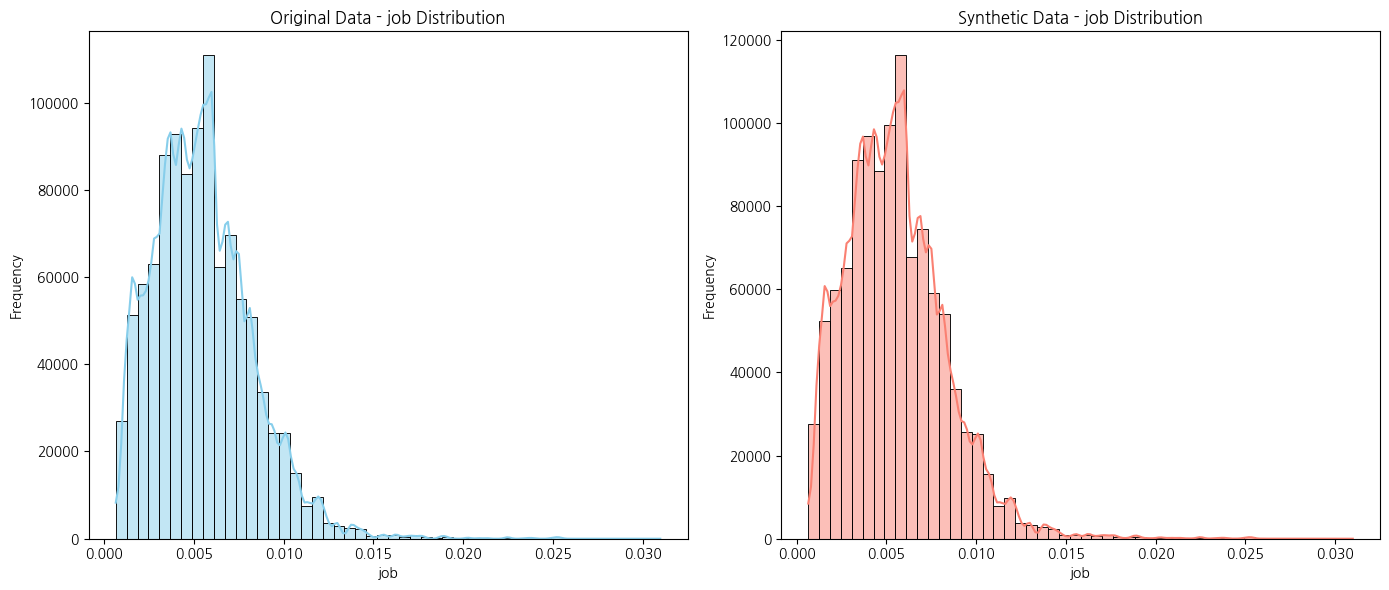

컬럼 'job' 분포 비교 완료.


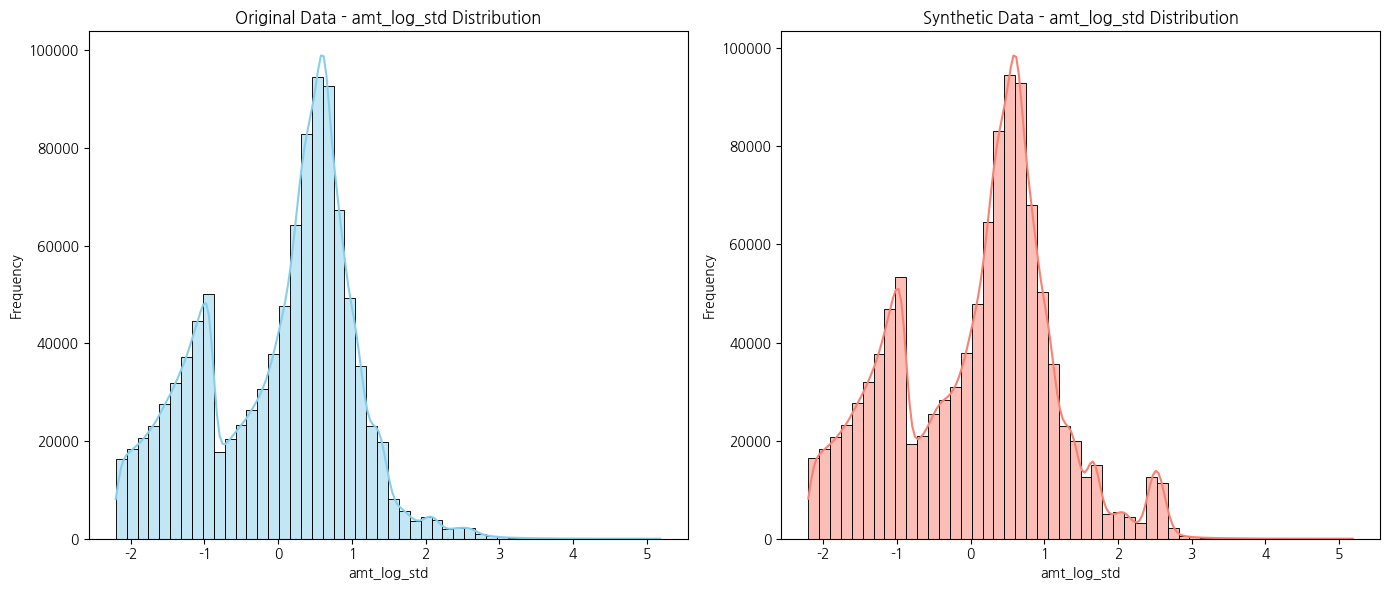

컬럼 'amt_log_std' 분포 비교 완료.


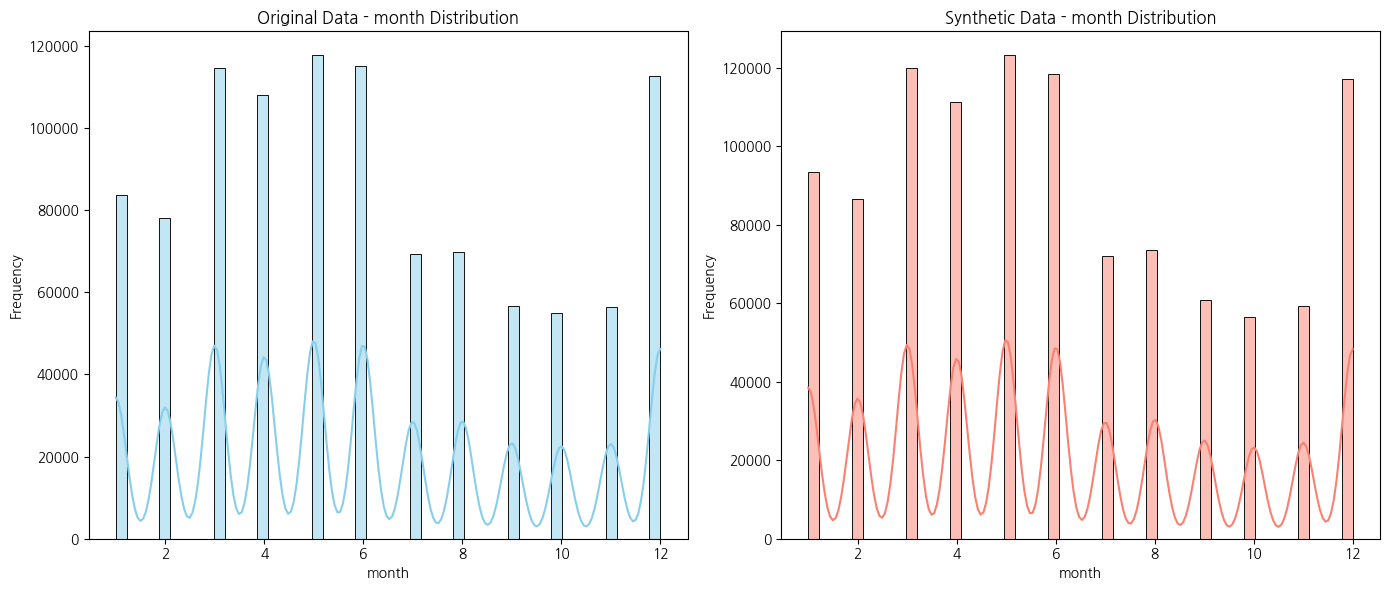

컬럼 'month' 분포 비교 완료.


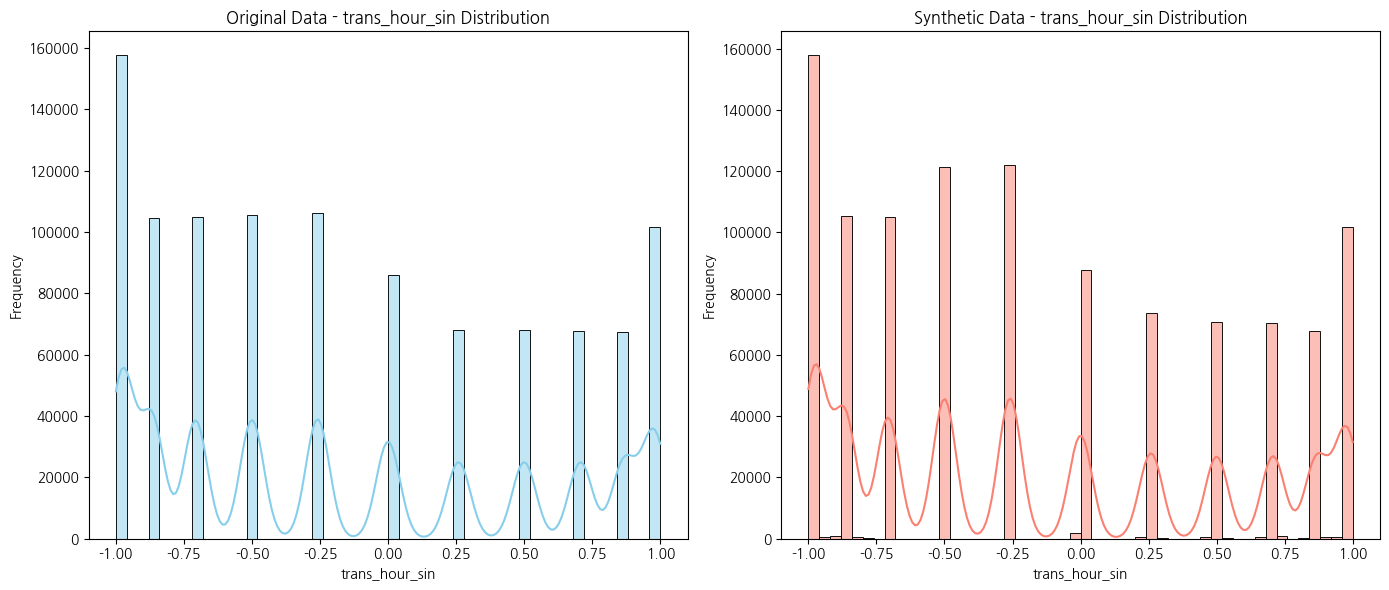

컬럼 'trans_hour_sin' 분포 비교 완료.


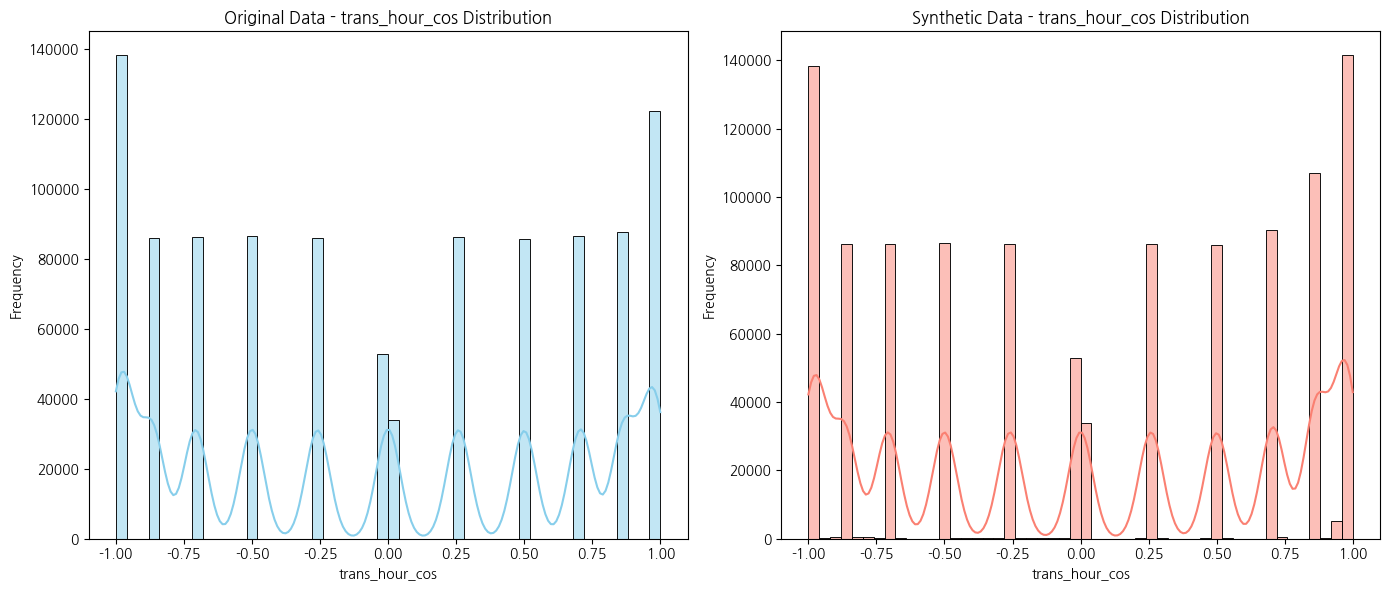

컬럼 'trans_hour_cos' 분포 비교 완료.


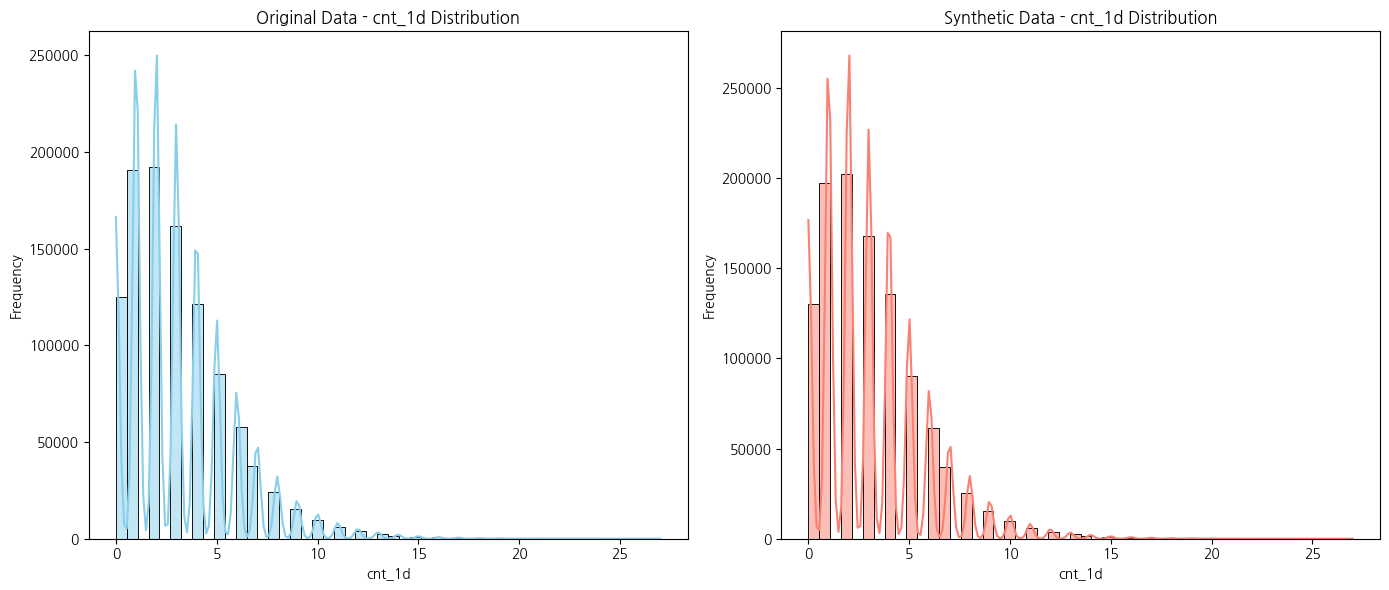

컬럼 'cnt_1d' 분포 비교 완료.


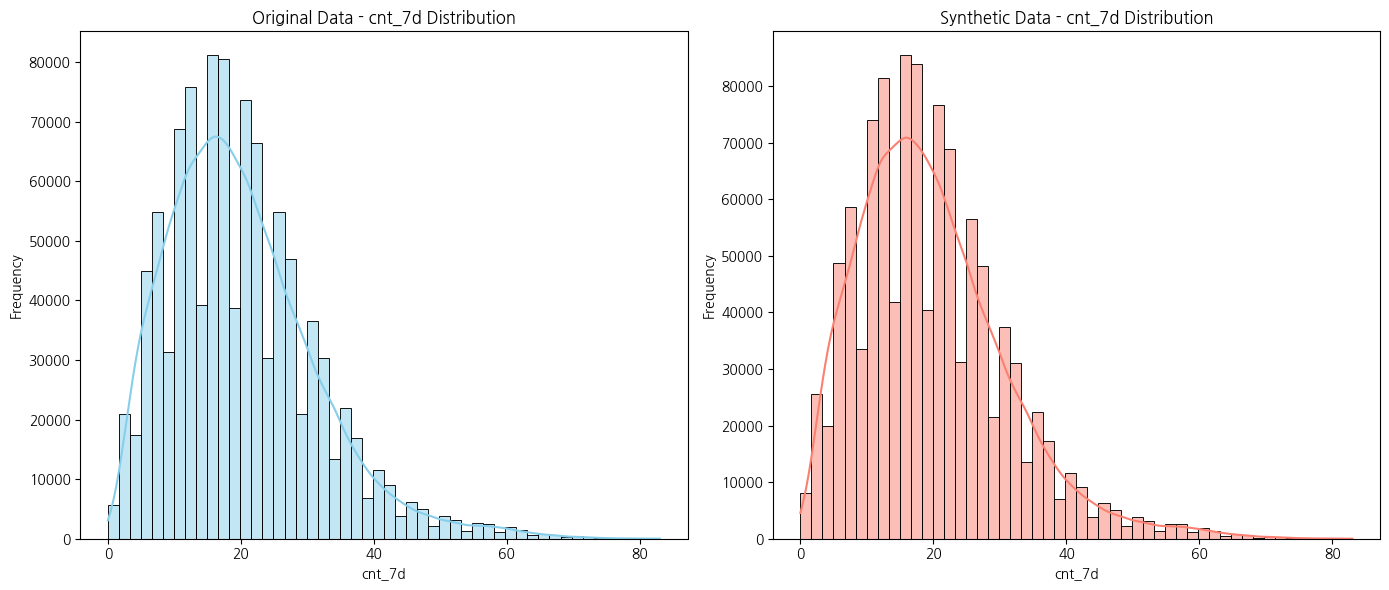

컬럼 'cnt_7d' 분포 비교 완료.


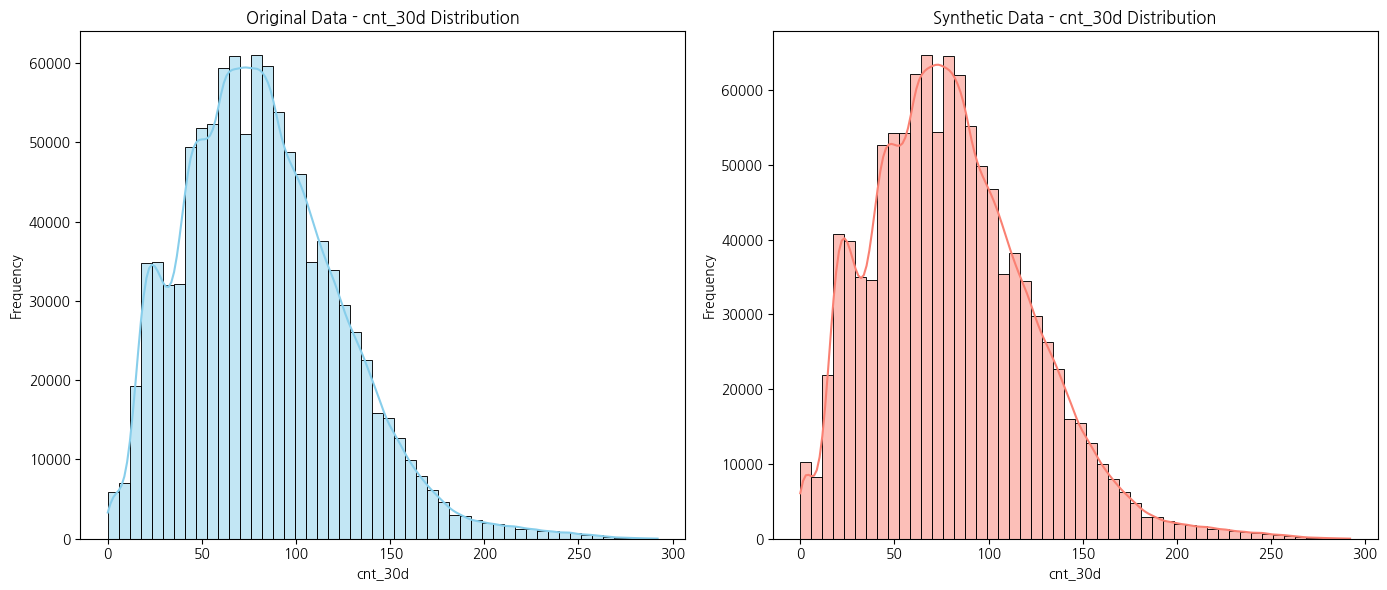

컬럼 'cnt_30d' 분포 비교 완료.


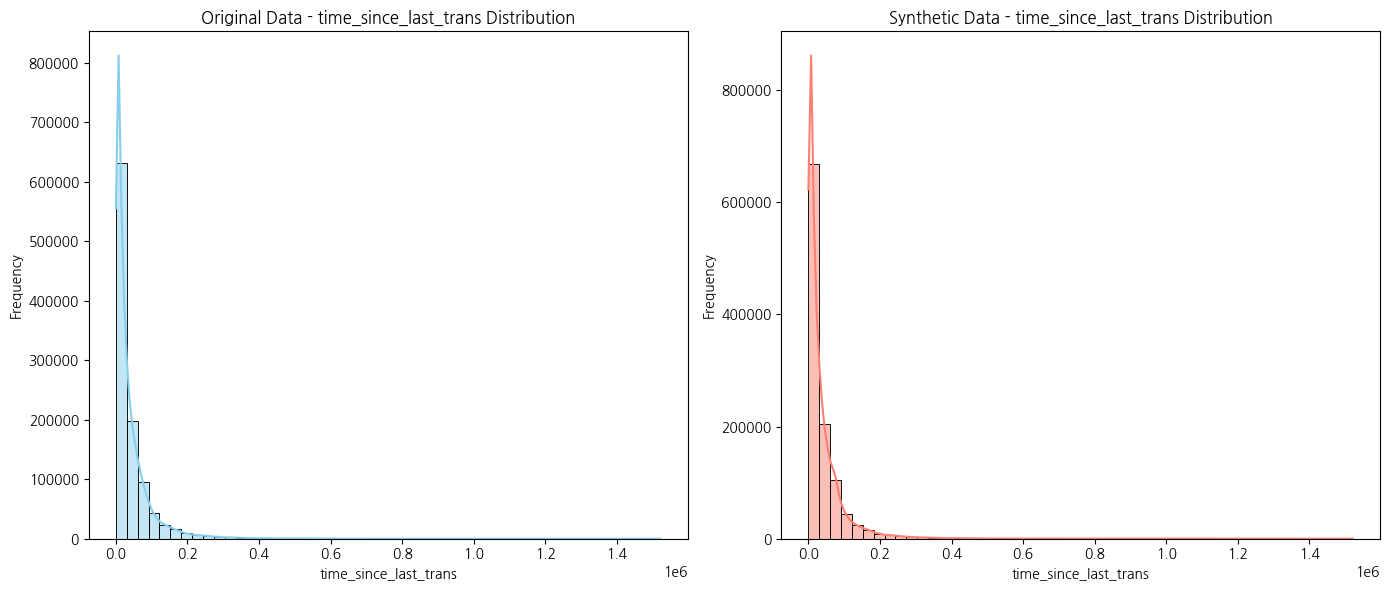

컬럼 'time_since_last_trans' 분포 비교 완료.


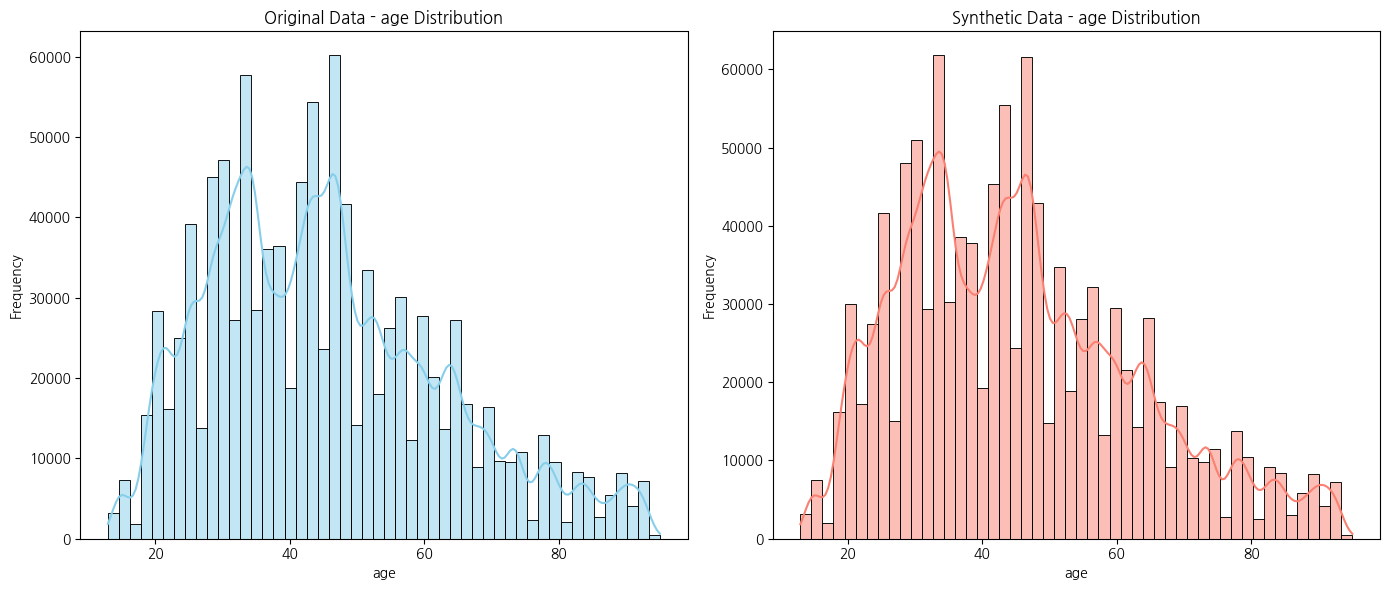

컬럼 'age' 분포 비교 완료.


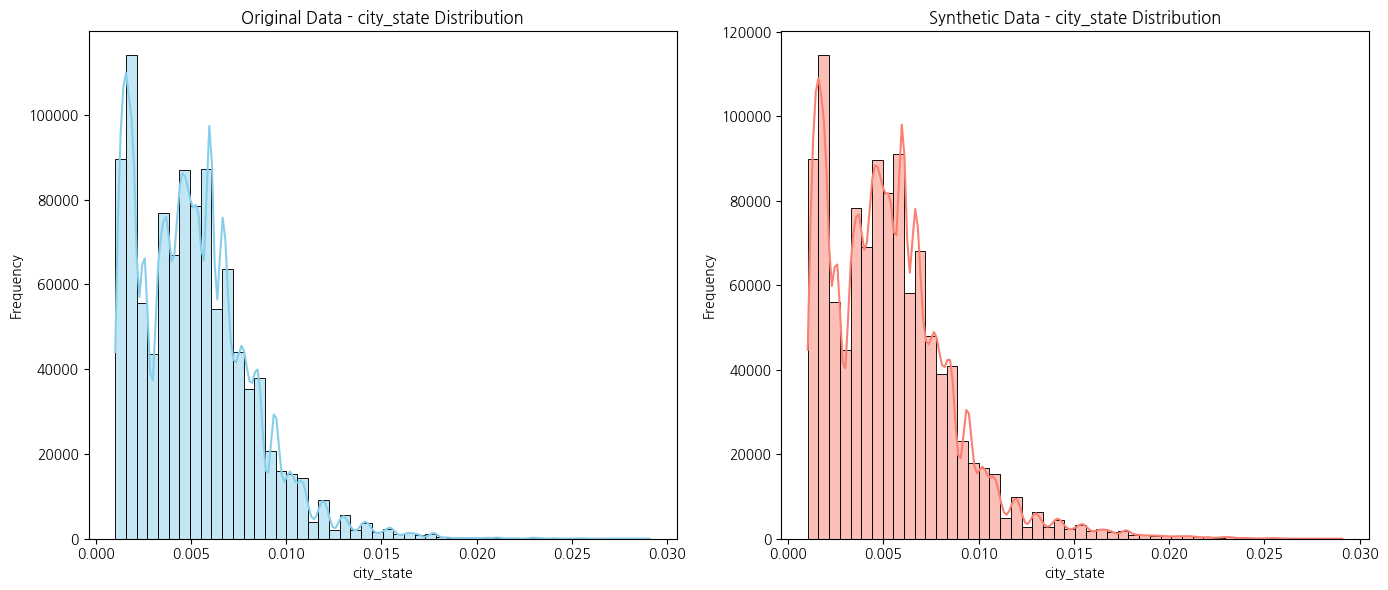

컬럼 'city_state' 분포 비교 완료.

--- 1.3. 수치형 컬럼과 타겟 'is_fraud' 관계 (박스플롯) ---


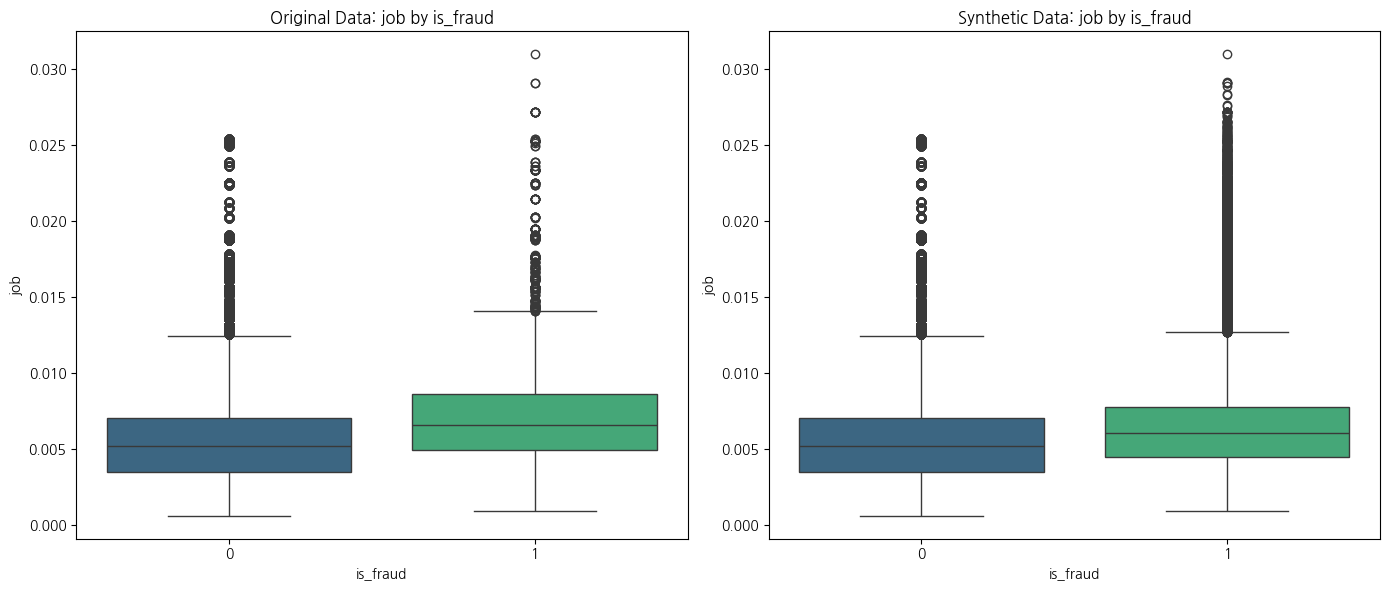

컬럼 'job'와 'is_fraud' 관계 비교 완료.


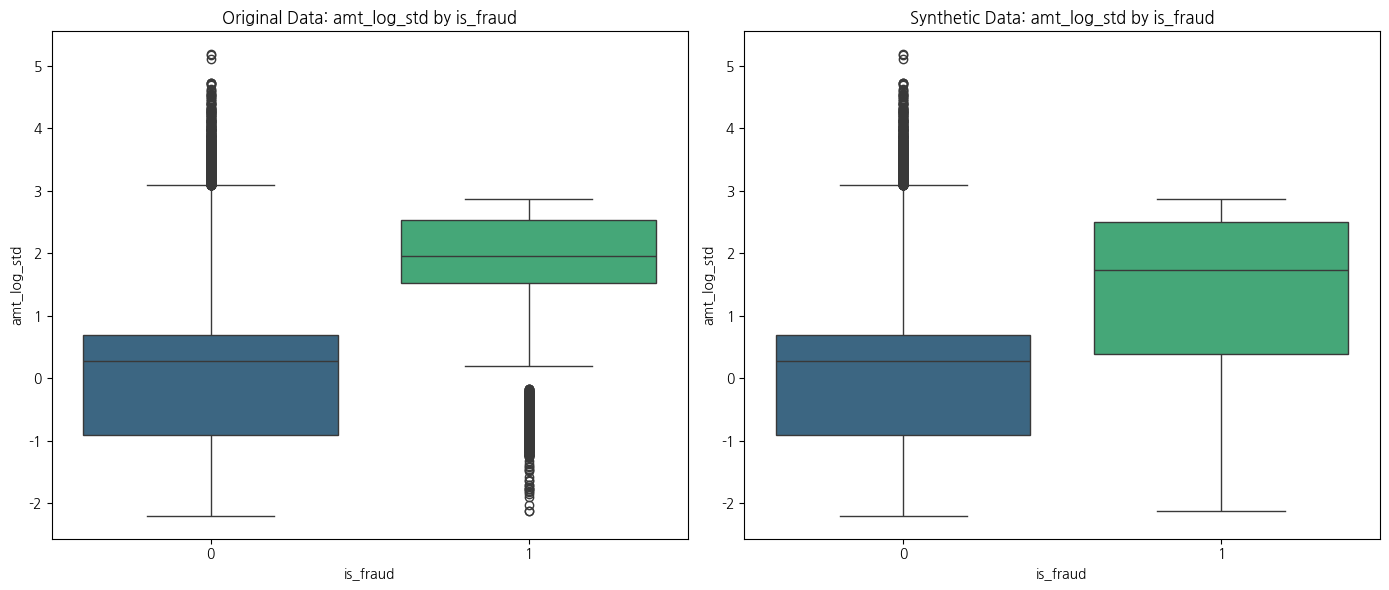

컬럼 'amt_log_std'와 'is_fraud' 관계 비교 완료.


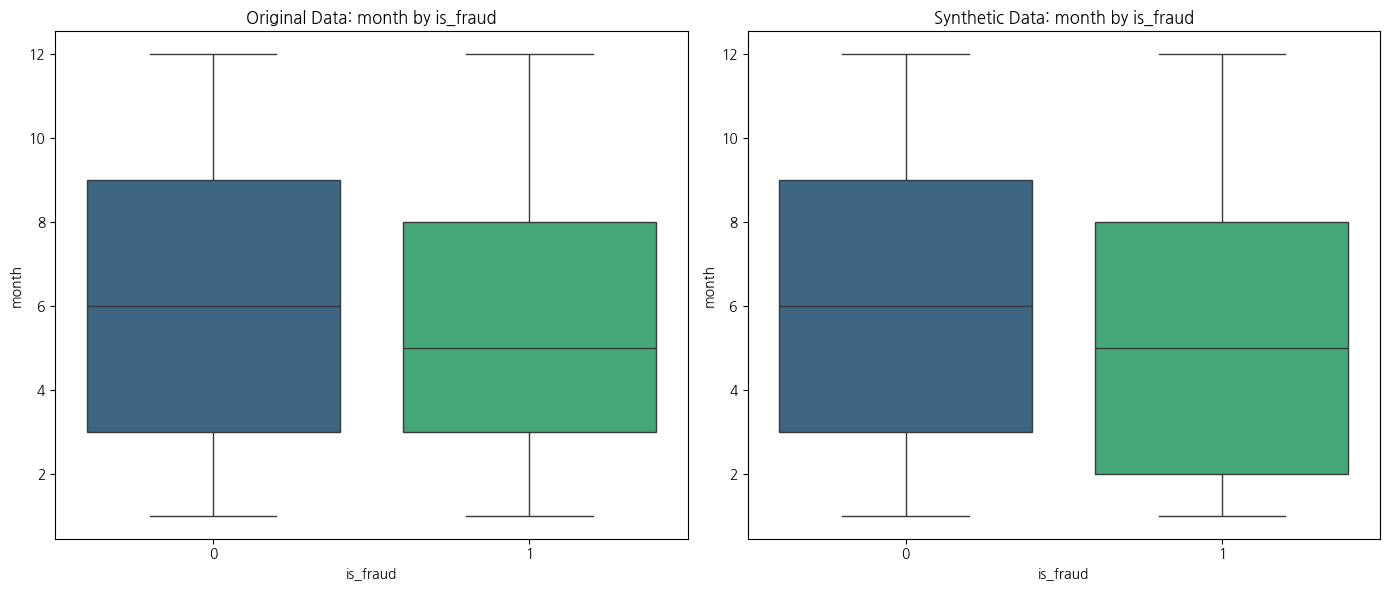

컬럼 'month'와 'is_fraud' 관계 비교 완료.


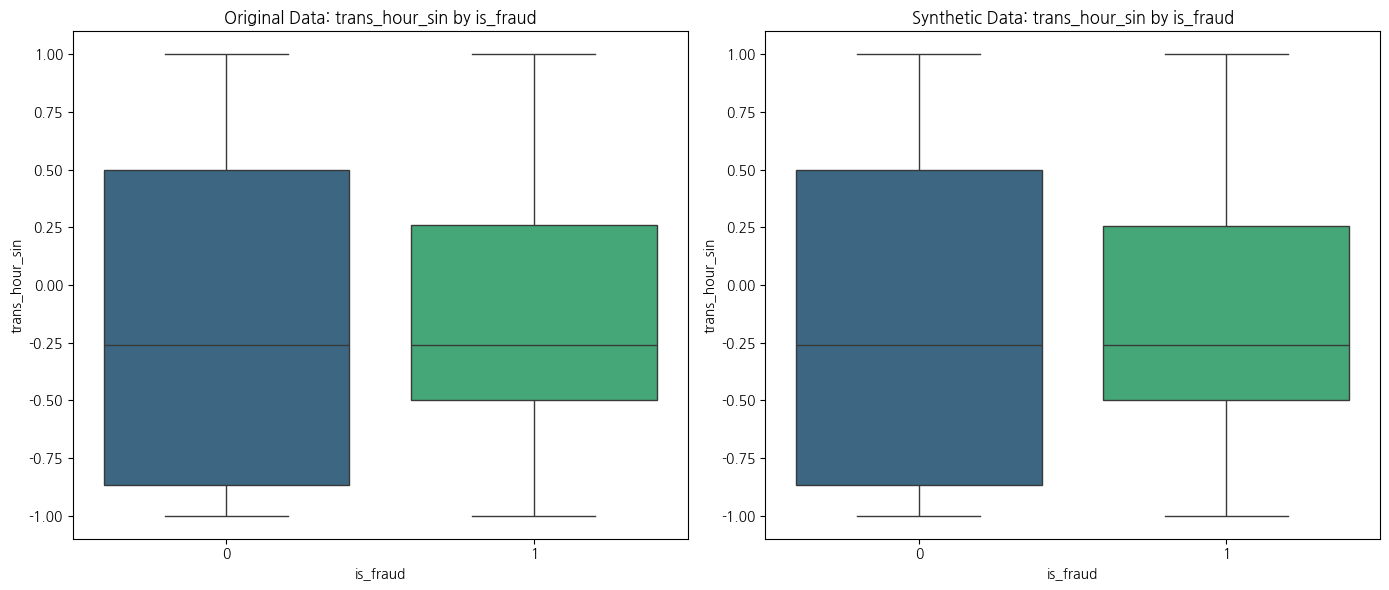

컬럼 'trans_hour_sin'와 'is_fraud' 관계 비교 완료.


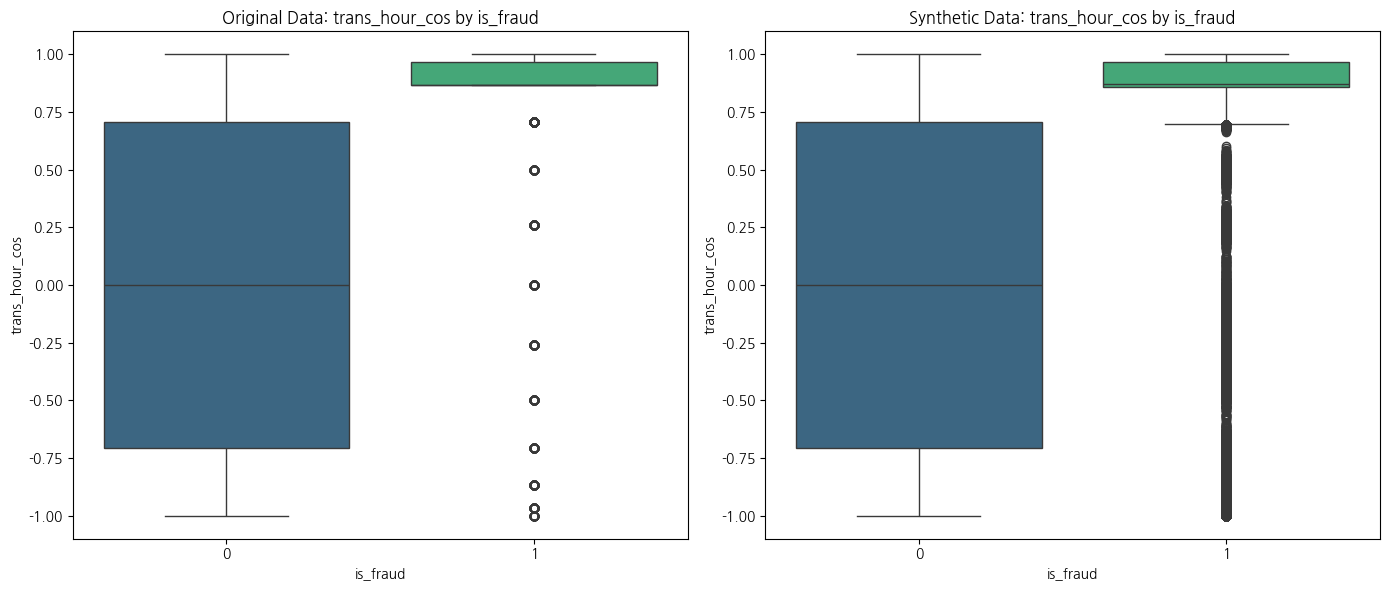

컬럼 'trans_hour_cos'와 'is_fraud' 관계 비교 완료.


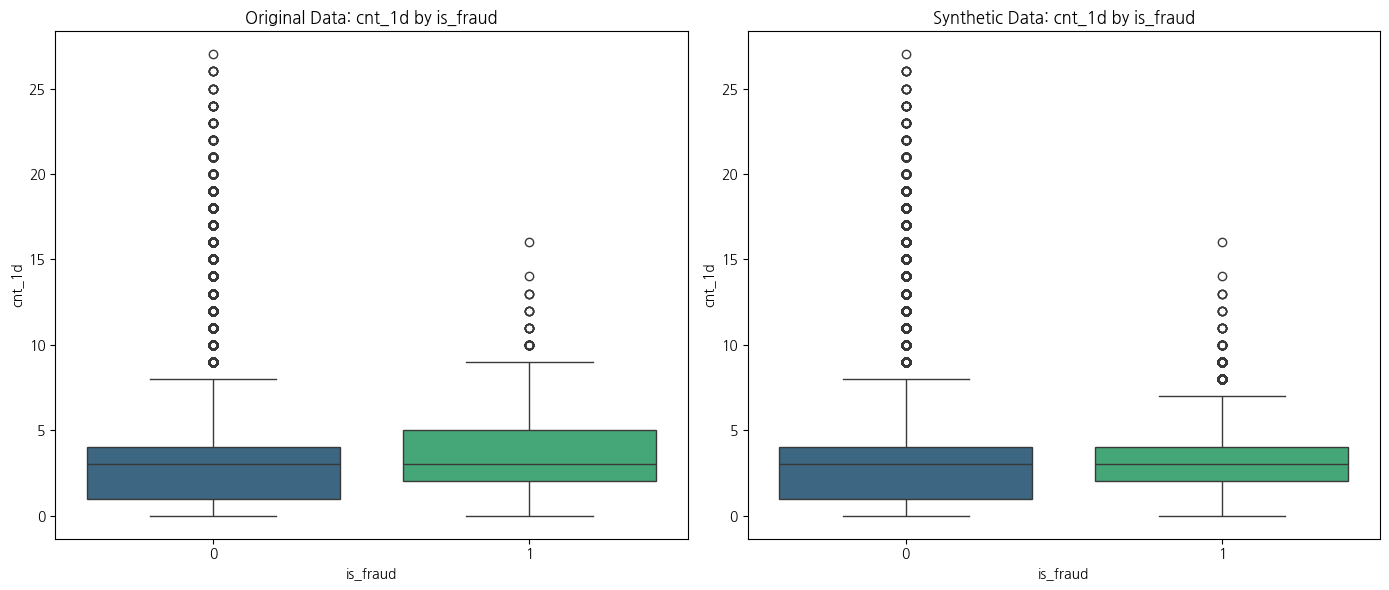

컬럼 'cnt_1d'와 'is_fraud' 관계 비교 완료.


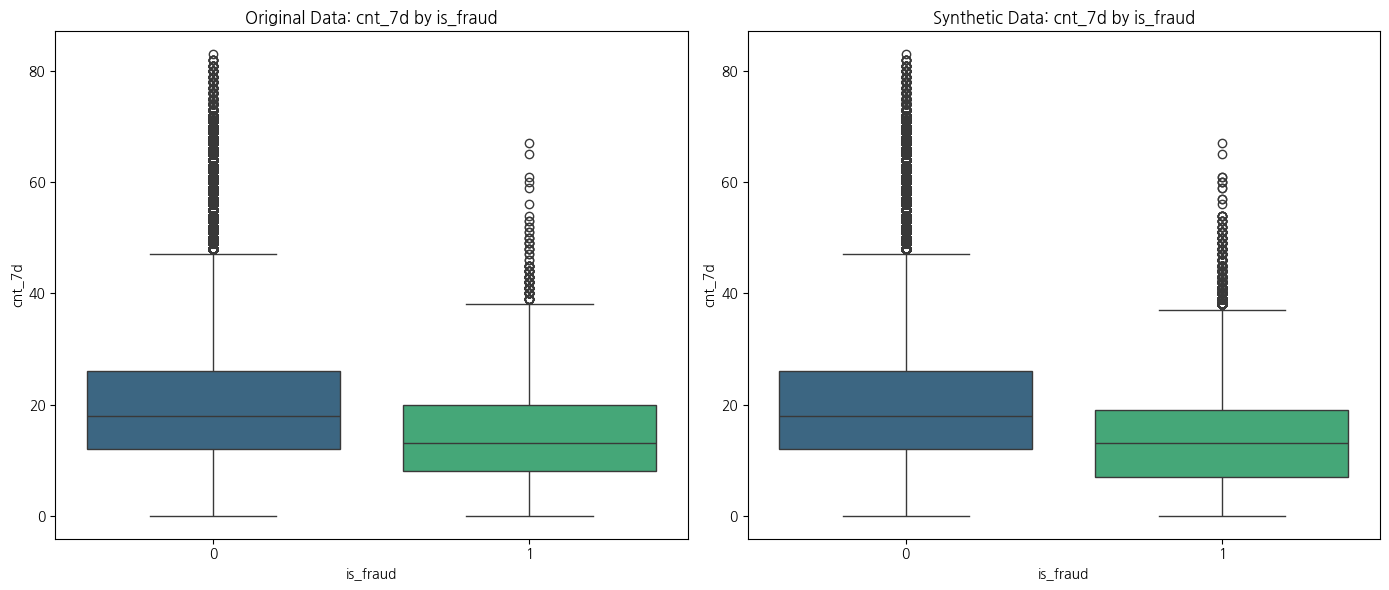

컬럼 'cnt_7d'와 'is_fraud' 관계 비교 완료.


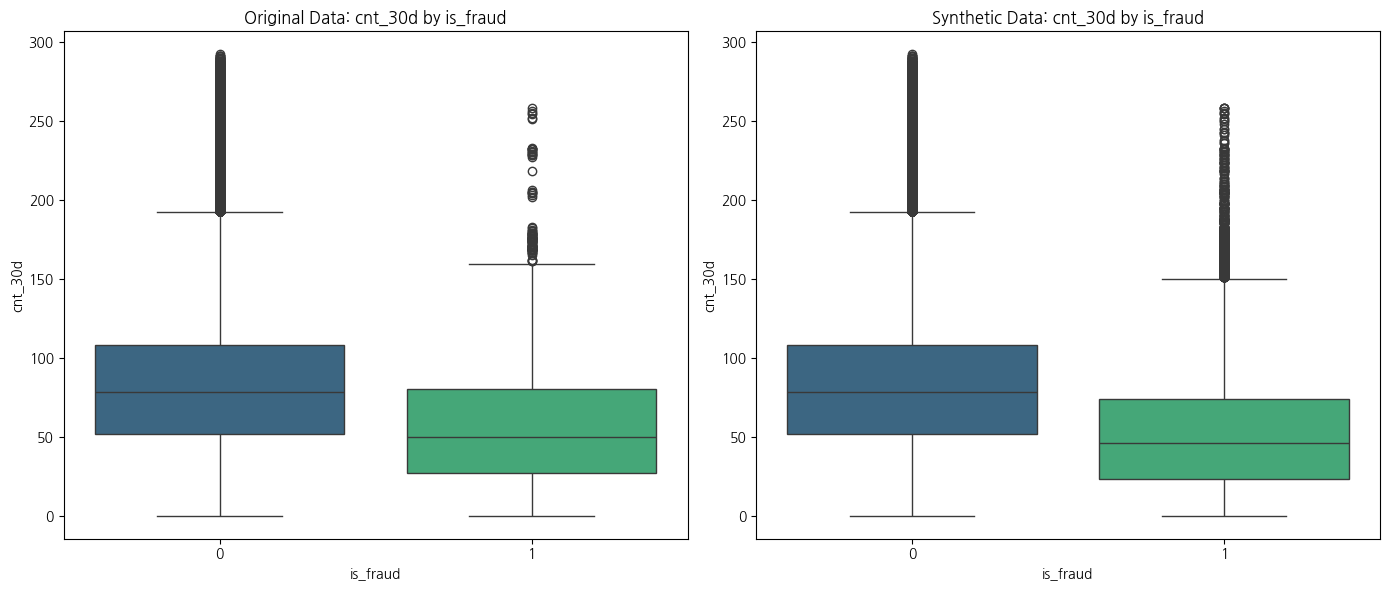

컬럼 'cnt_30d'와 'is_fraud' 관계 비교 완료.


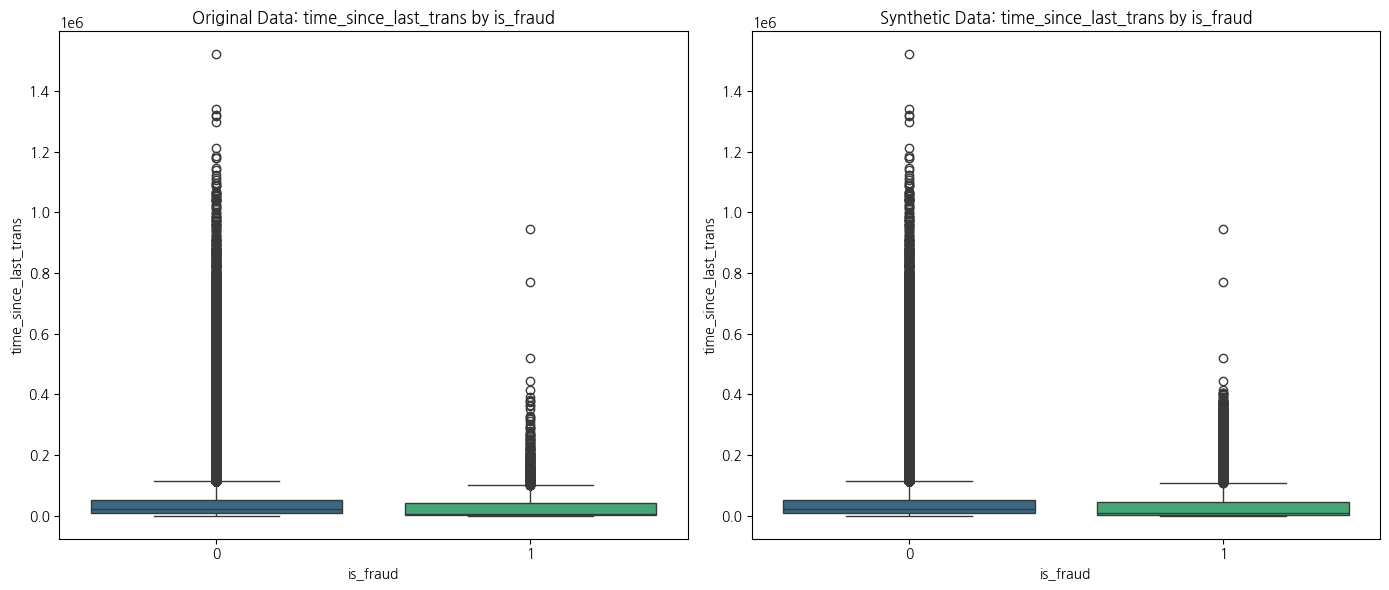

컬럼 'time_since_last_trans'와 'is_fraud' 관계 비교 완료.


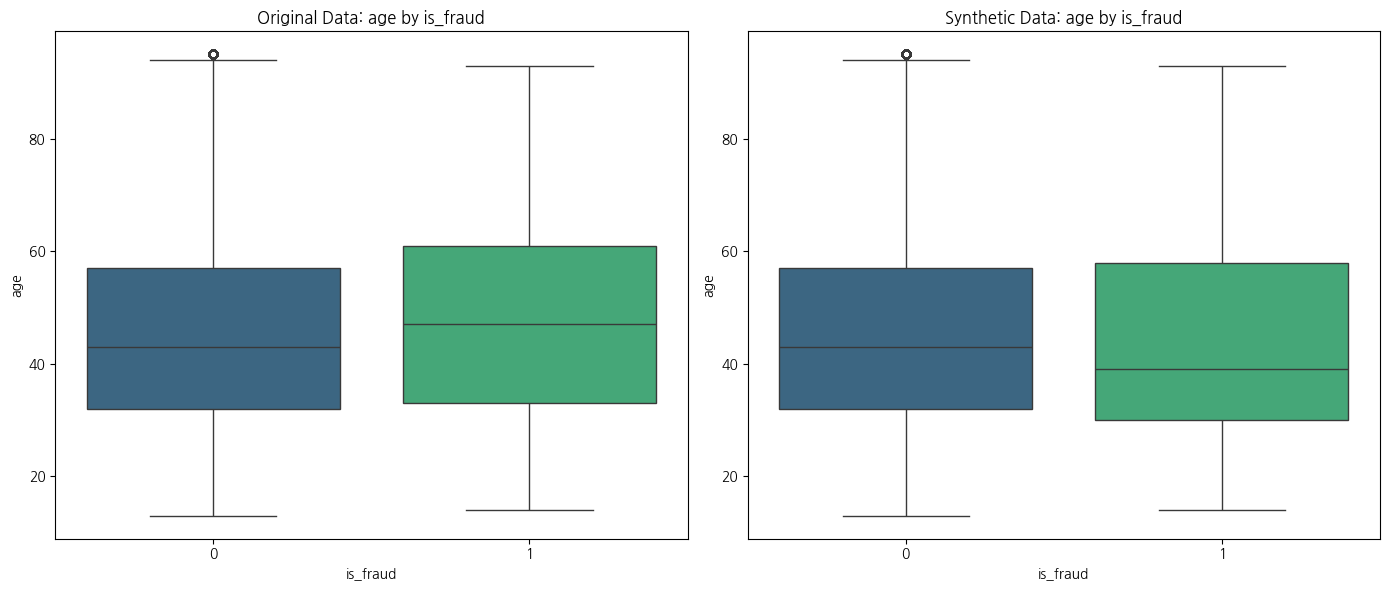

컬럼 'age'와 'is_fraud' 관계 비교 완료.


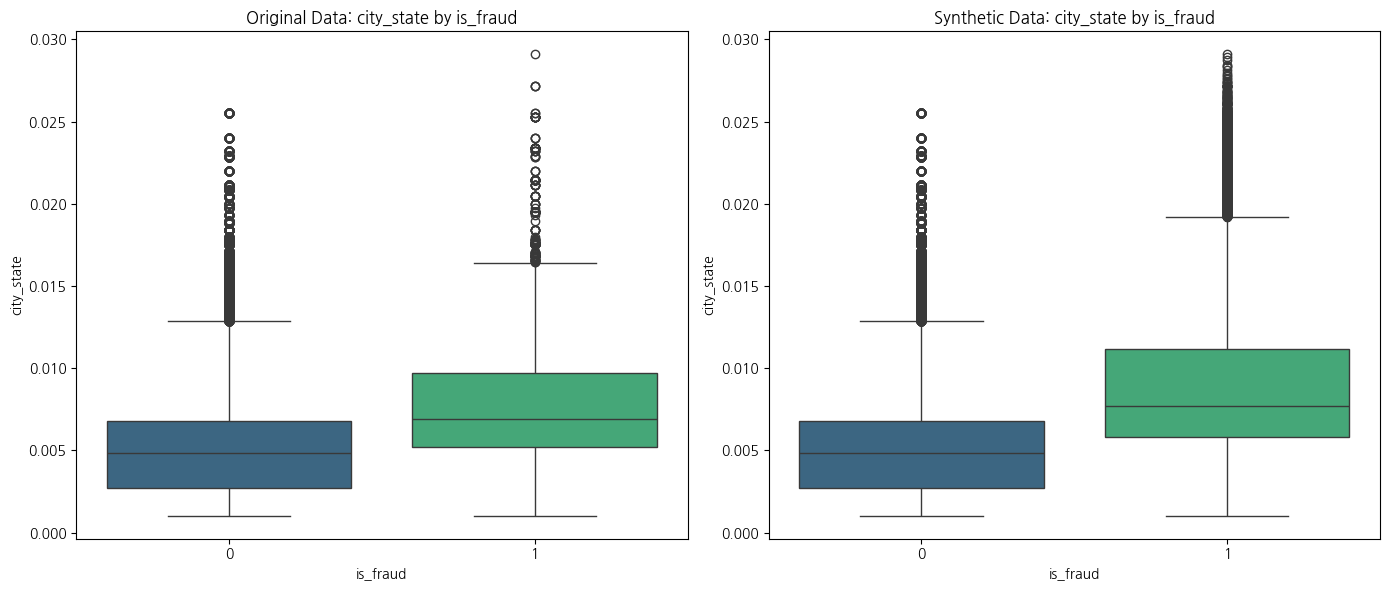

컬럼 'city_state'와 'is_fraud' 관계 비교 완료.

--- 1.4. 범주형 컬럼 분포 (Countplot) ---


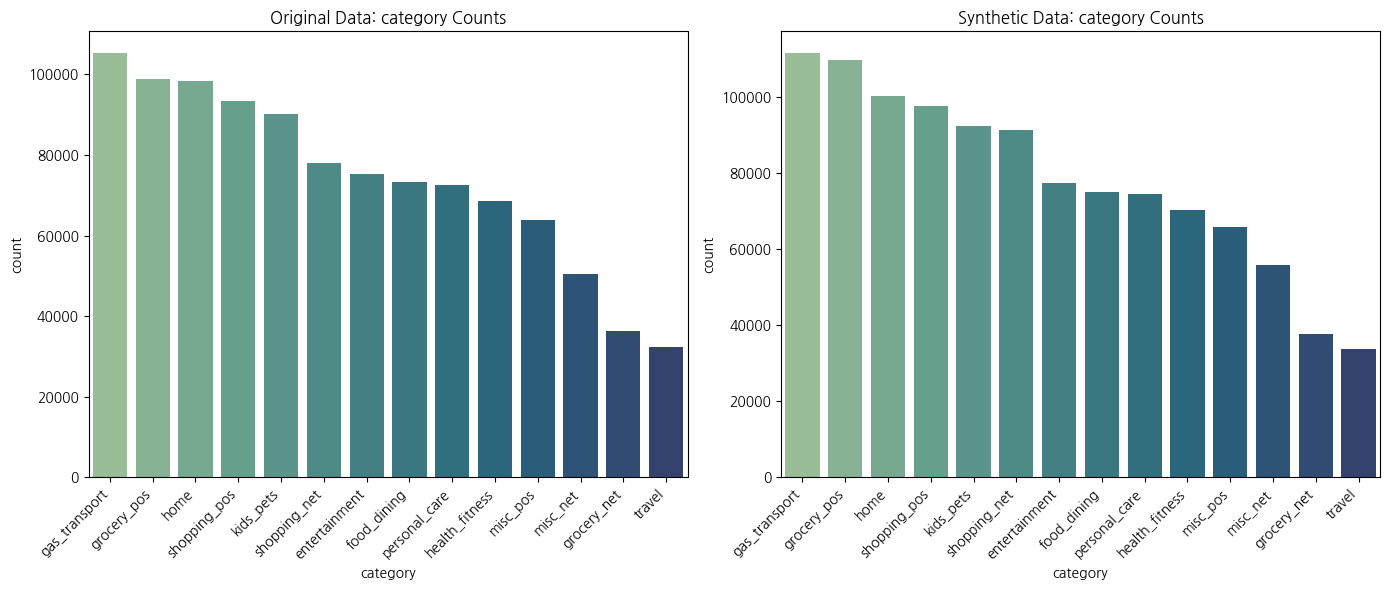

범주형 컬럼 'category' 분포 비교 완료.


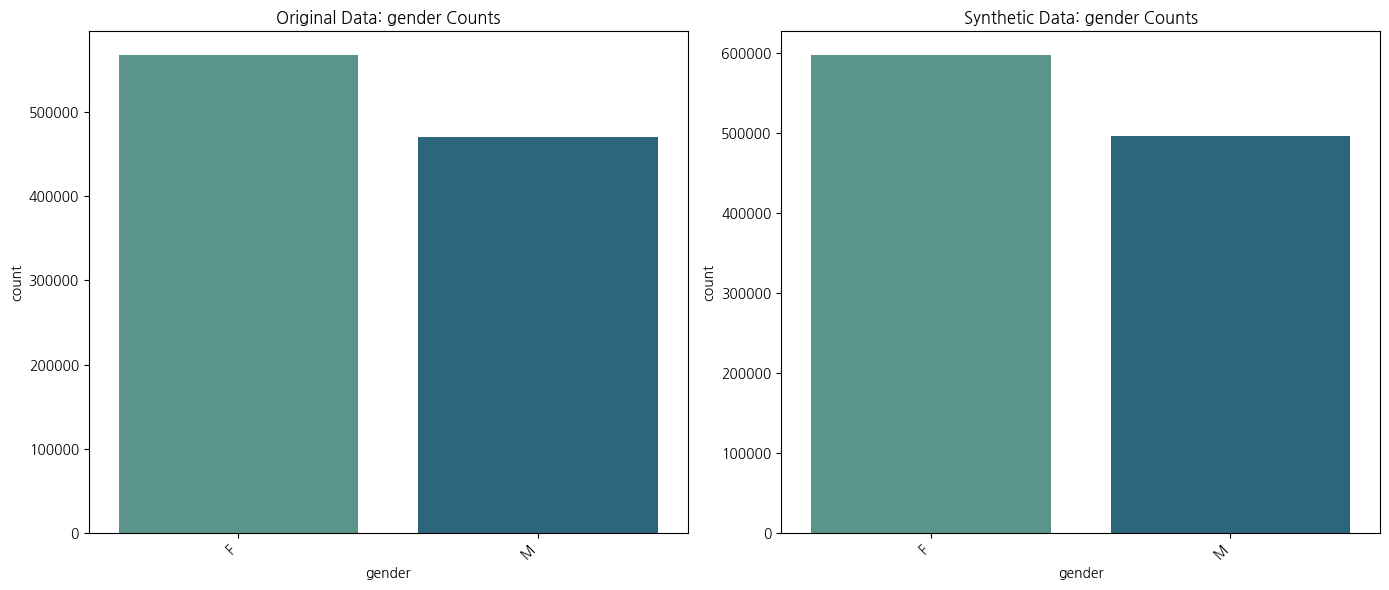

범주형 컬럼 'gender' 분포 비교 완료.


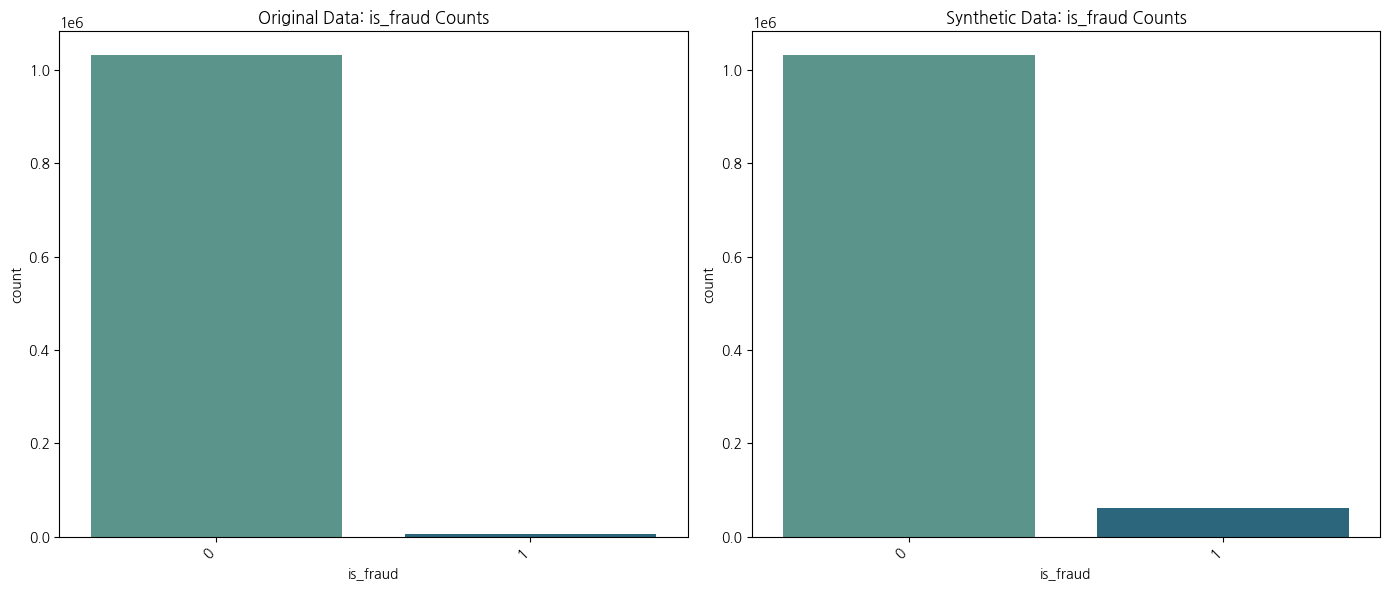

범주형 컬럼 'is_fraud' 분포 비교 완료.


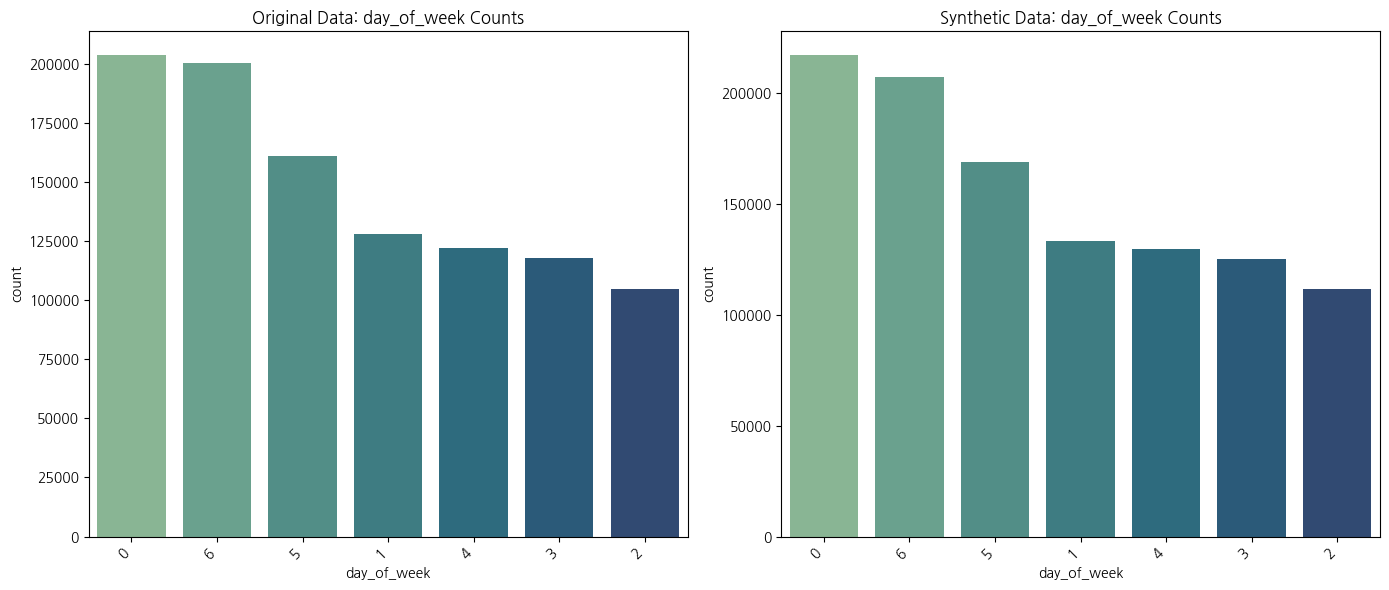

범주형 컬럼 'day_of_week' 분포 비교 완료.


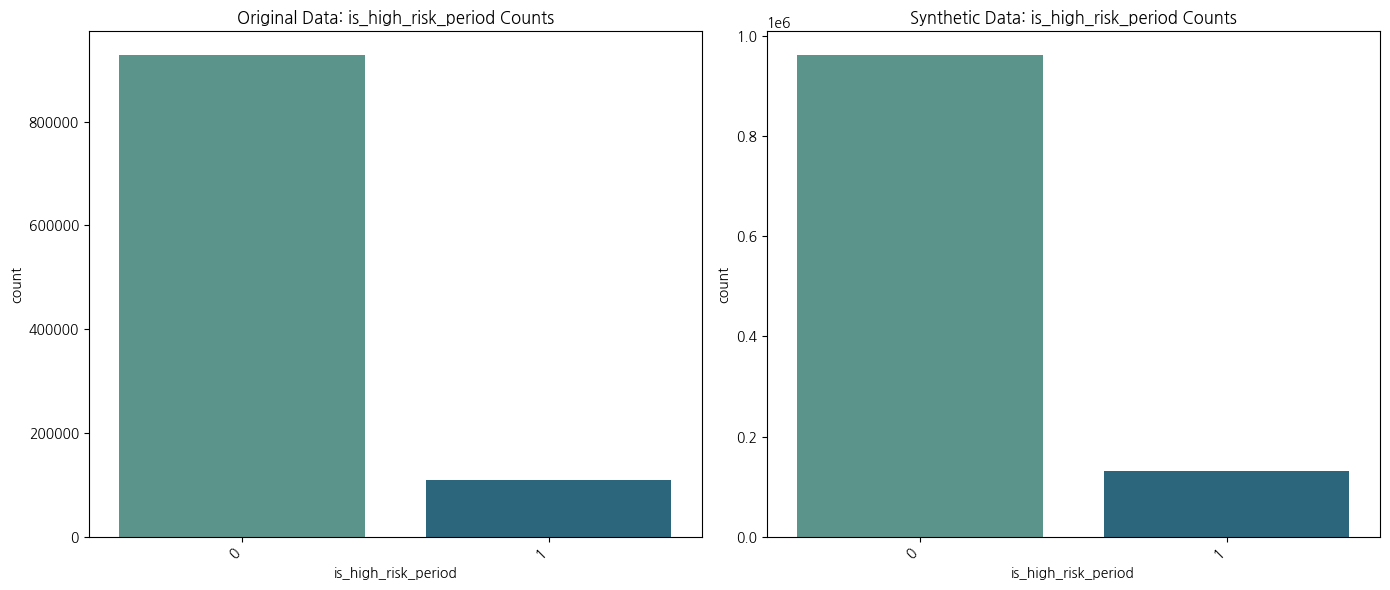

범주형 컬럼 'is_high_risk_period' 분포 비교 완료.

--- 2. 수치적 비교 ---

--- 원본 데이터 수치형 컬럼 기술 통계량 ---
                job   amt_log_std         month  trans_hour_sin  \
count  1.037340e+06  1.037340e+06  1.037340e+06    1.037340e+06   
mean   5.475903e-03 -2.252169e-16  6.142723e+00   -1.366832e-01   
std    2.755760e-03  1.000000e+00  3.416462e+00    6.932392e-01   
min    6.427764e-04 -2.202897e+00  1.000000e+00   -1.000000e+00   
25%    3.491938e-03 -9.056330e-01  3.000000e+00   -8.660254e-01   
50%    5.239505e-03  2.703071e-01  6.000000e+00   -2.588190e-01   
75%    7.098144e-03  6.968155e-01  9.000000e+00    5.000000e-01   
max    3.098328e-02  5.185360e+00  1.200000e+01    1.000000e+00   

       trans_hour_cos        cnt_1d        cnt_7d       cnt_30d  \
count    1.037340e+06  1.037340e+06  1.037340e+06  1.037340e+06   
mean    -1.406730e-02  3.104604e+00  2.005702e+01  8.237765e+01   
std      7.074886e-01  2.582770e+00  1.125348e+01  4.216015e+01   
min     -1.000000e+00  0.000000e+00  0.0

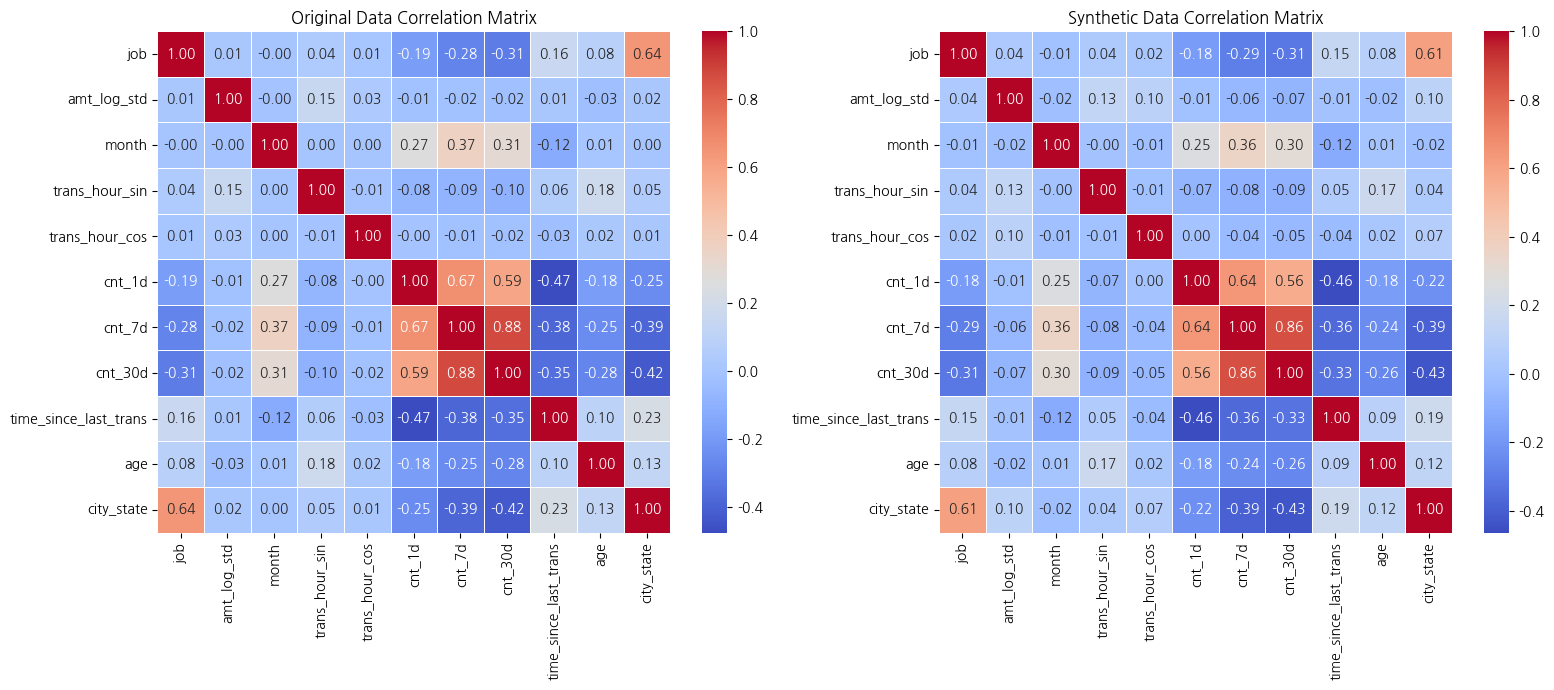


상관 행렬 비교 완료. 컬럼 간의 관계 유사성을 확인하세요.

--- 범주형 컬럼 비율 비교 ---

--- 컬럼 'category' 비율 ---
Original:
category
gas_transport     0.101617
grocery_pos       0.095250
home              0.094914
shopping_pos      0.089956
kids_pets         0.086973
shopping_net      0.075281
entertainment     0.072639
food_dining       0.070676
personal_care     0.070006
health_fitness    0.066201
misc_pos          0.061565
misc_net          0.048618
grocery_net       0.035038
travel            0.031267
Name: proportion, dtype: float64
Synthetic:
category
gas_transport     0.102127
grocery_pos       0.100353
home              0.091685
shopping_pos      0.089245
kids_pets         0.084446
shopping_net      0.083549
entertainment     0.070877
food_dining       0.068702
personal_care     0.068234
health_fitness    0.064202
misc_pos          0.060153
misc_net          0.051050
grocery_net       0.034525
travel            0.030852
Name: proportion, dtype: float64

--- 컬럼 'gender' 비율 ---
Original:
gender
F    0.546891
M

In [15]:
# ctgan_columns_info = {
#     'category': {'sdtype': 'categorical'},
#     'gender': {'sdtype': 'categorical'},
#     'job': {'sdtype': 'numerical'}, # 타겟 인코딩된 값으로 덮어쓰기 됨
#     'is_fraud': {'sdtype': 'categorical'}, # 타겟 변수
#     'amt_log_std': {'sdtype': 'numerical'},
#     'day_of_week': {'sdtype': 'categorical'},
#     'month': {'sdtype': 'numerical'},
#     'trans_hour_sin': {'sdtype': 'numerical'},
#     'trans_hour_cos': {'sdtype': 'numerical'},
#     'is_high_risk_period': {'sdtype': 'categorical'},
#     'cnt_1d': {'sdtype': 'numerical'},
#     'cnt_7d': {'sdtype': 'numerical'},
#     'cnt_30d': {'sdtype': 'numerical'},
#     'time_since_last_trans': {'sdtype': 'numerical'},
#     'age': {'sdtype': 'numerical'},
#     'city_state': {'sdtype': 'numerical'} # 타겟 인코딩된 값으로 덮어쓰기 됨
# }

ctgan_columns_info = metadata.columns

# 컬럼 타입을 분류
numerical_cols_to_compare = [col for col, info in ctgan_columns_info.items() if info['sdtype'] == 'numerical']
categorical_cols_to_compare = [col for col, info in ctgan_columns_info.items() if info['sdtype'] == 'categorical']

# 타겟 변수 설정 (sdtype이 categorical이지만, 중요하므로 별도로 지정)
target_col = 'is_fraud'

# 'is_fraud'가 numerical_cols_to_compare에 있다면 제거 (이진 범주형으로 가정)
if target_col in numerical_cols_to_compare:
    numerical_cols_to_compare.remove(target_col)

print(f"비교할 수치형 컬럼: {numerical_cols_to_compare}")
print(f"비교할 범주형 컬럼: {categorical_cols_to_compare}")
print(f"타겟 컬럼: {target_col}")

# --- 1. 시각적 비교 ---

print("\n--- 1. 시각적 비교: 분포 확인 ---")

# 1.1. 수치형 변수의 분포 (히스토그램) - 타겟 인코딩된 'job', 'city_state' 포함
print("\n--- 1.1. 수치형 컬럼 분포 (히스토그램) ---")
for col in numerical_cols_to_compare:
    # 컬럼이 두 DF에 모두 존재하는지 확인
    if col not in encoded_df_train_both_te.columns or col not in augmented_train_df.columns:
        print(f"Warning: 컬럼 '{col}'이 두 데이터프레임 중 하나에 없어 히스토그램 비교를 건너뜁니다.")
        continue

    plt.figure(figsize=(14, 6))

    # 원본 데이터 히스토그램
    plt.subplot(1, 2, 1)
    sns.histplot(encoded_df_train_both_te[col], kde=True, bins=50, color='skyblue')
    plt.title(f'Original Data - {col} Distribution')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    # 합성 데이터 히스토그램
    plt.subplot(1, 2, 2)
    sns.histplot(augmented_train_df[col], kde=True, bins=50, color='salmon')
    plt.title(f'Synthetic Data - {col} Distribution')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()
    print(f"컬럼 '{col}' 분포 비교 완료.")

# 1.2. 수치형 피처 vs 범주형 타겟 변수 (`is_fraud`) 관계 (박스플롯/바이올린플롯)
print(f"\n--- 1.3. 수치형 컬럼과 타겟 '{target_col}' 관계 (박스플롯) ---")
if target_col in categorical_cols_to_compare:
    for col in numerical_cols_to_compare:
        if col not in encoded_df_train_both_te.columns or col not in augmented_train_df.columns or \
           target_col not in encoded_df_train_both_te.columns or target_col not in augmented_train_df.columns:
            print(f"Warning: 컬럼 '{col}' 또는 '{target_col}'이 두 데이터프레임 중 하나에 없어 관계 비교를 건너뜁니다.")
            continue

        plt.figure(figsize=(14, 6))

        plt.subplot(1, 2, 1)
        sns.boxplot(x=encoded_df_train_both_te[target_col], y=encoded_df_train_both_te[col], palette='viridis')
        plt.title(f'Original Data: {col} by {target_col}')
        plt.xlabel(target_col)
        plt.ylabel(col)

        plt.subplot(1, 2, 2)
        sns.boxplot(x=augmented_train_df[target_col], y=augmented_train_df[col], palette='viridis')
        plt.title(f'Synthetic Data: {col} by {target_col}')
        plt.xlabel(target_col)
        plt.ylabel(col)

        plt.tight_layout()
        plt.show()
        print(f"컬럼 '{col}'와 '{target_col}' 관계 비교 완료.")
else:
    print(f"Warning: 타겟 컬럼 '{target_col}'이 범주형 컬럼 리스트에 없어 박스플롯 비교를 건너뜁니다.")


# 1.3. 범주형 컬럼의 분포 비교 (Countplot)
print("\n--- 1.4. 범주형 컬럼 분포 (Countplot) ---")
for col in categorical_cols_to_compare:
    if col not in encoded_df_train_both_te.columns or col not in augmented_train_df.columns:
        print(f"Warning: 컬럼 '{col}'이 두 데이터프레임 중 하나에 없어 Countplot 비교를 건너뜁니다.")
        continue

    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    # 범주 순서 유지를 위해 value_counts().index 사용
    sns.countplot(data=encoded_df_train_both_te, x=col, order=encoded_df_train_both_te[col].value_counts().index, palette='crest')
    plt.title(f'Original Data: {col} Counts')
    plt.xticks(rotation=45, ha='right')

    plt.subplot(1, 2, 2)
    sns.countplot(data=augmented_train_df, x=col, order=augmented_train_df[col].value_counts().index, palette='crest')
    plt.title(f'Synthetic Data: {col} Counts')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    print(f"범주형 컬럼 '{col}' 분포 비교 완료.")


# --- 2. 수치적 비교 ---

print("\n--- 2. 수치적 비교 ---")

# 2.1. 기술 통계량 (Descriptive Statistics)
# 모든 수치형 컬럼에 대해 기술 통계량 비교
print("\n--- 원본 데이터 수치형 컬럼 기술 통계량 ---")
print(encoded_df_train_both_te[numerical_cols_to_compare].describe())

print("\n--- 합성 데이터 수치형 컬럼 기술 통계량 ---")
print(augmented_train_df[numerical_cols_to_compare].describe())

print("\n기술 통계량 비교 완료. 평균, 표준편차, 사분위수 등을 확인하세요.")


# 2.2. 상관계수 (Correlation Coefficient) - 수치형 컬럼만 해당
print("\n--- 원본 데이터 수치형 컬럼 상관 행렬 ---")
corr_original = encoded_df_train_both_te[numerical_cols_to_compare].corr()
print(corr_original)

print("\n--- 합성 데이터 수치형 컬럼 상관 행렬 ---")
corr_synthetic = augmented_train_df[numerical_cols_to_compare].corr()
print(corr_synthetic)

# 상관 행렬 시각화
plt.figure(figsize=(16, 7))

plt.subplot(1, 2, 1)
sns.heatmap(corr_original, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Original Data Correlation Matrix')

plt.subplot(1, 2, 2)
sns.heatmap(corr_synthetic, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Synthetic Data Correlation Matrix')

plt.tight_layout()
plt.show()

print("\n상관 행렬 비교 완료. 컬럼 간의 관계 유사성을 확인하세요.")


# 2.3. 범주형 변수의 비율 비교
print("\n--- 범주형 컬럼 비율 비교 ---")
for col in categorical_cols_to_compare:
    if col in encoded_df_train_both_te.columns and col in augmented_train_df.columns:
        print(f"\n--- 컬럼 '{col}' 비율 ---")
        print("Original:")
        print(encoded_df_train_both_te[col].value_counts(normalize=True))
        print("Synthetic:")
        print(augmented_train_df[col].value_counts(normalize=True))
    else:
        print(f"Warning: 컬럼 '{col}'이 두 데이터프레임 중 하나에 없어 비율 비교를 건너뜁니다.")


In [ ]:
optimal_m_job = best_m_param_combination['m_job']
optimal_m_city_state = best_m_param_combination['m_city_state']
selected_m_param_combination_key = (optimal_m_job, optimal_m_city_state) # m_param_data_storage의 키 형태로 만듭니다.

print(f"\n{'='*80}")
print(f"--- 2단계: 최적 M-param 조합 (job_m={optimal_m_job}, city_state_m={optimal_m_city_state})으로 전체 모델 랜덤 서치 시작 ---")
print(f"{'='*80}")

# 최적 M-param 조합으로 전처리된 데이터셋 로드
print(f"\n[최종 튜닝] M-param 조합 (job_m={optimal_m_job}, city_state_m={optimal_m_city_state})에 해당하는 데이터셋 로드...")
final_tuning_data = m_param_data_storage[selected_m_param_combination_key]

X_train_final_tuning = final_tuning_data['X_train']
y_train_final_tuning = final_tuning_data['y_train']
X_val_final_tuning = final_tuning_data['X_val']
y_val_final_tuning = final_tuning_data['y_val']
X_test_final_tuning = final_tuning_data['X_test']
y_test_final_tuning = final_tuning_data['y_test'] # 테스트셋 타겟도 가져옴

print("  최종 튜닝 데이터셋 로드 완료.")
print(f"  X_train_final_tuning shape: {X_train_final_tuning.shape}")

# --- 모델별 파이프라인 및 param_distributions 정의 ---

# LightGBM 파이프라인
lgbm_params = {'random_state': 42, 'n_jobs': -1}
if use_gpu:
    lgbm_params['device'] = 'gpu'
pipeline_lgbm = Pipeline([
    ('classifier', lgb.LGBMClassifier(**lgbm_params)) # preprocessor 완전히 제거
])
lgbm_param_distributions = {
    'classifier__n_estimators': [200, 500],
    'classifier__learning_rate': [0.01, 0.05],
    'classifier__num_leaves': [31, 63],
    'classifier__max_depth': [7, -1],
    'classifier__min_child_samples': [20, 50],
    'classifier__subsample': [0.8, 1.0],
    'classifier__colsample_bytree': [0.8, 1.0],
    'classifier__reg_alpha': [0, 0.1],
    'classifier__reg_lambda': [0, 0.1]
}

# XGBoost 파이프라인
xgb_params = {'random_state': 42, 'n_jobs': -1, 'eval_metric': 'logloss', 'use_label_encoder': False}
if use_gpu:
    xgb_params['tree_method'] = 'gpu_hist'
pipeline_xgb = Pipeline([
    ('classifier', XGBClassifier(**xgb_params)) # preprocessor 완전히 제거
])
xgb_param_distributions = {
    'classifier__n_estimators': [200, 500],
    'classifier__learning_rate': [0.01, 0.05],
    'classifier__max_depth': [3, 5, 7],
    'classifier__min_child_weight': [1, 5],
    'classifier__subsample': [0.8, 1.0],
    'classifier__colsample_bytree': [0.8, 1.0],
    'classifier__gamma': [0, 0.1],
    'classifier__lambda': [1, 10],
    'classifier__alpha': [0, 0.1]
}

# CatBoost 파이프라인 (이전과 동일하게 preprocessor 없음)
cat_params = {'random_state': 42, 'verbose': 0}
if use_gpu:
    cat_params['task_type'] = 'GPU'
pipeline_cat = Pipeline([
    ('classifier', CatBoostClassifier(**cat_params))
])
cat_param_distributions = {
    'classifier__iterations': [200, 500],
    'classifier__learning_rate': [0.01, 0.05],
    'classifier__depth': [5, 7],
    'classifier__l2_leaf_reg': [1, 3, 5],
    'classifier__subsample': [0.8, 1.0],
    'classifier__rsm': [0.8, 1.0]
}

# 최종 랜덤 서치 실행
cv_strategy_final_tuning = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

best_overall_lgbm = {'score': -1.0, 'model': None}
best_overall_xgb = {'score': -1.0, 'model': None}
best_overall_cat = {'score': -1.0, 'model': None}


# LightGBM RandomizedSearchCV
print(f"\n[최종 튜닝] LightGBM 모델 랜덤 서치 시작 (n_iter=10)...")
random_search_lgbm = RandomizedSearchCV(
    estimator=pipeline_lgbm,
    param_distributions=lgbm_param_distributions,
    n_iter=10,
    cv=cv_strategy_final_tuning,
    scoring='f1',
    n_jobs=-1,
    verbose=1,
    random_state=42
)
random_search_lgbm.fit(X_train_final_tuning, y_train_final_tuning)
print(f"   -> LightGBM 최적 하이퍼파라미터: {random_search_lgbm.best_params_}")
print(f"   -> LightGBM 최고 F1 스코어: {random_search_lgbm.best_score_:.4f}")
best_overall_lgbm['score'] = random_search_lgbm.best_score_
best_overall_lgbm['model'] = random_search_lgbm.best_estimator_


# XGBoost RandomizedSearchCV
print(f"\n[최종 튜닝] XGBoost 모델 랜덤 서치 시작 (n_iter=10)...")
random_search_xgb = RandomizedSearchCV(
    estimator=pipeline_xgb,
    param_distributions=xgb_param_distributions,
    n_iter=10,
    cv=cv_strategy_final_tuning,
    scoring='f1',
    n_jobs=-1,
    verbose=1,
    random_state=42
)
random_search_xgb.fit(X_train_final_tuning, y_train_final_tuning)
print(f"   -> XGBoost 최적 하이퍼파라미터: {random_search_xgb.best_params_}")
print(f"   -> XGBoost 최고 F1 스코어: {random_search_xgb.best_score_:.4f}")
best_overall_xgb['score'] = random_search_xgb.best_score_
best_overall_xgb['model'] = random_search_xgb.best_estimator_


# CatBoost RandomizedSearchCV
print(f"\n[최종 튜닝] CatBoost 모델 랜덤 서치 시작 (n_iter=10)...")
random_search_cat = RandomizedSearchCV(
    estimator=pipeline_cat,
    param_distributions=cat_param_distributions,
    n_iter=10,
    cv=cv_strategy_final_tuning,
    scoring='f1',
    n_jobs=-1,
    verbose=1,
    random_state=42
)
random_search_cat.fit(X_train_final_tuning, y_train_final_tuning)
print(f"   -> CatBoost 최적 하이퍼파라미터: {random_search_cat.best_params_}")
print(f"   -> CatBoost 최고 F1 스코어: {random_search_cat.best_score_:.4f}")
best_overall_cat['score'] = random_search_cat.best_score_
best_overall_cat['model'] = random_search_cat.best_estimator_


# --- 모든 모델에 대한 최종 랜덤 서치 완료 ---
print(f"\n{'='*80}")
print("--- 2단계: 모든 모델에 대한 최종 랜덤 서치 완료 ---")
print(f"{'='*80}")

print("\n\n--- 최종 모델별 최적 F1 스코어 ---")
print(f"LightGBM: Best F1 = {best_overall_lgbm['score']:.4f}")
print(f"XGBoost:  Best F1 = {best_overall_xgb['score']:.4f}")
print(f"CatBoost: Best F1 = {best_overall_cat['score']:.4f}")


--- 2단계: 최적 M-param (500)으로 전체 모델 랜덤 서치 시작 ---

[최종 튜닝] M-param 500에 해당하는 데이터셋 로드...
  최종 튜닝 데이터셋 로드 완료.
  X_train_final_tuning shape: (1092340, 29)

[최종 튜닝] LightGBM 모델 랜덤 서치 시작 (n_iter=10)...
Fitting 3 folds for each of 10 candidates, totalling 30 fits


In [ ]:
# --- 앙상블 모델 재구성 ---
meta_clf = LogisticRegression(random_state=42)

model_configs_optimized = {
    'Voting (LGBM, XGB, CatBoost) - Optimized': VotingClassifier(
        estimators=[
            ('lgbm', best_overall_lgbm['model']),
            ('xgb', best_overall_xgb['model']),
            ('cat', best_overall_cat['model'])
        ],
        voting='soft',
        n_jobs=-1
    ),
    'Stacking (LGBM, XGB, CatBoost) - Optimized': StackingClassifier(
        estimators=[
            ('lgbm', best_overall_lgbm['model']),
            ('xgb', best_overall_xgb['model']),
            ('cat', best_overall_cat['model'])
        ],
        final_estimator=meta_clf,
        cv=3,
        n_jobs=-1
    )
}

print("\n--- 최적화된 Pipeline으로 재구성된 앙상블 설정 ---")
print(model_configs_optimized)

In [ ]:
# --- 앙상블 모델 학습 및 평가 ---
print("\n\n[최종 단계] 앙상블 모델 학습 및 평가 시작...")
final_ensemble_results_summary = []

for name, model in model_configs_optimized.items():
    print(f"\n\n{'='*70}\n--- 모델: {name} ---\n{'='*70}")

    print("학습 시작...")
    model.fit(X_train_final_tuning, y_train_final_tuning)
    print("학습 완료.")

    # 검증 데이터 평가
    print(f"\n--- {name} - Validation Set 평가 ---")
    evaluate_and_visualize(model, X_val_final_tuning, y_val_final_tuning, f"{name} Validation Set")

    # 테스트 데이터 평가
    print(f"\n--- {name} - Test Set 평가 ---")
    test_results = evaluate_and_visualize(model, X_test_final_tuning, y_test_final_tuning, f"{name} Test Set")
    test_results['Model'] = name
    final_ensemble_results_summary.append(test_results)

In [ ]:
# --- 최종 결과 요약 및 시각화 ---
print(f"\n\n{'='*70}\n 최종 결과 요약 (Test Set 기준)\n{'='*70}")
summary_df = pd.DataFrame(final_ensemble_results_summary).set_index('Model')
print(summary_df.to_string())

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax1 = plt.subplots(figsize=(14, 8))
summary_df[['F1-Score', 'ROC_AUC']].sort_values(by='F1-Score').plot(kind='bar', ax=ax1, width=0.8)
ax1.set_title('앙상블 모델별 최종 성능 비교 (Test Set)', fontsize=18)
ax1.set_xlabel('모델 조합', fontsize=12)
ax1.set_ylabel('Score', fontsize=12)
ax1.tick_params(axis='x', rotation=10)
ax1.legend(loc='upper left', bbox_to_anchor=(0.01, 0.95))
ax1.grid(axis='y', linestyle='--')
for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontsize=10)
plt.tight_layout()
plt.show()